# 4.4. Сравнение с точными и классическими решателями

# 4.4.1. Brute force на малых графах

В этом разделе проверяется полная задача поиска торговой пары.

В отличие от раздела 4.3, здесь рассматривается уже не абстрактная Ising-модель, а QUBO-задача поиска минимального валидного цикла:

$$
0 \to \text{short} \to \ldots \to \text{long} \to 0.
$$

Для малых графов точное решение можно получить полным перебором всех допустимых простых путей между реальными вершинами. Это решение используется как эталон для сравнения с bSB и dSB.

In [16]:
import numpy as np
import pandas as pd
import itertools
import time
import matplotlib.pyplot as plt
import sys

sys.path.append('курсовая_2')

from market_graph import build_market_weights
from qubo_cycle import build_cycle_qubo
from ising_mapping import qubo_to_ising
from pair_search import verify_single_dummy_cycle, extract_pair_and_weight
from SB_modules import BSB, DSB

In [ ]:
def path_weight(path_nodes, w):
    """
    Вес пути short -> ... -> long без dummy-рёбер.
    """
    total = 0.0

    for a, b in zip(path_nodes[:-1], path_nodes[1:]):
        total += float(w[a, b])

    return total


def decode_edges_from_z(z, var_map):
    """
    Переводит бинарный QUBO-вектор z в список выбранных рёбер.
    """
    z = np.asarray(z, dtype=int).reshape(-1)

    selected_edges = []

    for u, bit in enumerate(z):
        if bit == 1:
            selected_edges.append(var_map.u2e[u])

    return selected_edges


def qubo_energy(z, lin, quad):
    """
    E(z) = sum_i lin_i z_i + sum_{i<j} quad_ij z_i z_j
    """
    z = np.asarray(z, dtype=float).reshape(-1)

    E = float(np.dot(lin, z))

    for (u, v), q in quad.items():
        E += float(q) * z[u] * z[v]

    return E

In [ ]:
def brute_force_best_dummy_cycle(w):
    """
    Точный поиск лучшего валидного цикла:

        0 -> short -> ... -> long -> 0

    Перебираются все простые обходные пути между реальными вершинами.
    Dummy-рёбра имеют нулевой вес, поэтому стоимость цикла равна
    стоимости пути между реальными вершинами.
    """
    w = np.asarray(w, dtype=float)
    N = w.shape[0] - 1

    nodes = list(range(1, N + 1))

    best = None
    rows = []

    for k in range(2, N + 1):
        for path in itertools.permutations(nodes, k):
            path = list(path)

            short_node = path[0]
            long_node = path[-1]
            weight = path_weight(path, w)

            cycle = [0] + path + [0]
            selected_edges = list(zip(cycle[:-1], cycle[1:]))

            row = {
                "cycle": cycle,
                "selected_edges": selected_edges,
                "short_node": short_node,
                "long_node": long_node,
                "path_nodes": path,
                "path_length": len(path),
                "path_weight": weight,
            }

            rows.append(row)

            if best is None or weight < best["path_weight"] - 1e-12:
                best = row

    all_cycles_df = pd.DataFrame(rows).sort_values(
        "path_weight"
    ).reset_index(drop=True)

    return best, all_cycles_df

In [ ]:
def generate_toy_market_graph(N, seed=None):
    """
    Генерирует небольшой игрушечный рыночный граф.

    ask/bid строятся вокруг случайной нормированной цены.
    схожесть (s) симметрична и лежит в [0,1].
    """
    rng = np.random.default_rng(seed)

    mid = rng.uniform(0.95, 1.05, size=N)
    spread = rng.uniform(0.002, 0.01, size=N)

    bid = mid - spread / 2
    ask = mid + spread / 2

    raw_sim = rng.uniform(0.2, 1.0, size=(N, N))
    sim = 0.5 * (raw_sim + raw_sim.T)
    np.fill_diagonal(sim, 0.0)

    w = build_market_weights(
        ask=ask,
        bid=bid,
        sim=sim,
    )

    return {
        "N": N,
        "ask": ask,
        "bid": bid,
        "sim": sim,
        "w": w,
    }

In [20]:
toy = generate_toy_market_graph(N=4, seed=42)

w_toy = toy["w"]

w_toy_df = pd.DataFrame(
    w_toy,
    index=["dummy"] + [f"A{i}" for i in range(1, toy["N"] + 1)],
    columns=["dummy"] + [f"A{i}" for i in range(1, toy["N"] + 1)],
)

w_toy_df

,dummy,A1,A2,A3,A4
dummy,0.0,0.000000,0.000000,0.000000,0.000000
A1,0.0,0.000000,-0.017364,0.007917,-0.001868
A2,0.0,0.025372,0.000000,0.020515,0.015100
A3,0.0,-0.001735,-0.013305,0.000000,-0.006672
A4,0.0,0.011518,-0.007270,0.020445,0.000000


In [21]:
best_exact_toy, all_cycles_toy_df = brute_force_best_dummy_cycle(w_toy)

best_exact_toy

{'cycle': [0, 3, 1, 2, 0],
 'selected_edges': [(0, 3), (3, 1), (1, 2), (2, 0)],
 'short_node': 3,
 'long_node': 2,
 'path_nodes': [3, 1, 2],
 'path_length': 3,
 'path_weight': -0.01909859530172286}

In [22]:
all_cycles_toy_df.head(10)[
    ["cycle", "short_node", "long_node", "path_nodes", "path_length", "path_weight"]
]

,cycle,short_node,long_node,path_nodes,path_length,path_weight
0,"[0, 3, 1, 2, 0]",3,2,"[3, 1, 2]",3,-0.019099
1,"[0, 1, 2, 0]",1,2,"[1, 2]",2,-0.017364
2,"[0, 3, 4, 2, 0]",3,2,"[3, 4, 2]",3,-0.013943
3,"[0, 3, 2, 0]",3,2,"[3, 2]",2,-0.013305
4,"[0, 3, 4, 1, 2, 0]",3,2,"[3, 4, 1, 2]",4,-0.012518
5,"[0, 3, 1, 4, 2, 0]",3,2,"[3, 1, 4, 2]",4,-0.010874
6,"[0, 1, 4, 2, 0]",1,2,"[1, 4, 2]",3,-0.009139
7,"[0, 4, 2, 0]",4,2,"[4, 2]",2,-0.007270
8,"[0, 3, 4, 0]",3,4,"[3, 4]",2,-0.006672
9,"[0, 1, 3, 4, 2, 0]",1,2,"[1, 3, 4, 2]",4,-0.006026


In [23]:
ok, cycle = verify_single_dummy_cycle(
    selected_edges=best_exact_toy["selected_edges"],
    N=toy["N"],
)

assert ok
assert cycle == best_exact_toy["cycle"]

short_node, long_node, path_nodes, extracted_weight = extract_pair_and_weight(
    cycle=cycle,
    w=w_toy,
)

assert short_node == best_exact_toy["short_node"]
assert long_node == best_exact_toy["long_node"]
assert path_nodes == best_exact_toy["path_nodes"]
assert np.isclose(extracted_weight, best_exact_toy["path_weight"])

print("Exact brute force cycle is valid.")

Exact brute force cycle is valid.


In [ ]:
def run_sb_on_cycle_qubo(
    w,
    variant="BSB",
    n_runs=10,
    n_iter=500,
    dt=0.5,
    seed=42,
    mc=1.0,
    mp=None,
):
    """
    Строит QUBO -> Ising, запускает bSB/dSB несколько раз,
    декодирует решения и возвращает лучший валидный цикл.
    """
    w = np.asarray(w, dtype=float)
    N = w.shape[0] - 1

    lin, quad, var_map = build_cycle_qubo(
        w=w,
        tabu=None,
        mc=mc,
        mp=mp,
    )

    J, h, const = qubo_to_ising(lin, quad)

    rows = []
    best_valid = None

    for r in range(n_runs):
        run_seed = seed + r

        if variant.upper() == "BSB":
            solver = BSB(J, h=h, n_iter=n_iter, dt=dt, seed=run_seed)
        elif variant.upper() == "DSB":
            solver = DSB(J, h=h, n_iter=n_iter, dt=dt, seed=run_seed)
        else:
            raise ValueError("variant must be 'BSB' or 'DSB'")

        start = time.perf_counter()
        solver.run(record_trajectory=False)
        runtime_sec = time.perf_counter() - start

        x_final = solver.x.reshape(-1)
        s_final = np.where(x_final >= 0.0, 1, -1)
        z_final = ((s_final + 1) // 2).astype(int)

        selected_edges = decode_edges_from_z(z_final, var_map)

        ok, cycle = verify_single_dummy_cycle(
            selected_edges=selected_edges,
            N=N,
        )

        E_qubo = qubo_energy(z_final, lin, quad)

        row = {
            "variant": variant.upper(),
            "run": r,
            "seed": run_seed,
            "ok": ok,
            "cycle": cycle,
            "selected_edges": selected_edges,
            "E_qubo": E_qubo,
            "runtime_sec": runtime_sec,
        }

        if ok:
            short_node, long_node, path_nodes, pw = extract_pair_and_weight(
                cycle=cycle,
                w=w,
            )

            row.update({
                "short_node": short_node,
                "long_node": long_node,
                "path_nodes": path_nodes,
                "path_weight": pw,
            })

            if best_valid is None or pw < best_valid["path_weight"] - 1e-12:
                best_valid = row.copy()

        else:
            row.update({
                "short_node": None,
                "long_node": None,
                "path_nodes": None,
                "path_weight": np.nan,
            })

        rows.append(row)

    runs_df = pd.DataFrame(rows)

    return best_valid, runs_df

In [25]:
SB_DT = 0.5
SB_N_ITER = 500
SB_N_RUNS = 10
SB_SEED = 123

In [26]:
best_bsb_toy, runs_bsb_toy = run_sb_on_cycle_qubo(
    w=w_toy,
    variant="BSB",
    n_runs=SB_N_RUNS,
    n_iter=SB_N_ITER,
    dt=SB_DT,
    seed=SB_SEED,
)

best_dsb_toy, runs_dsb_toy = run_sb_on_cycle_qubo(
    w=w_toy,
    variant="DSB",
    n_runs=SB_N_RUNS,
    n_iter=SB_N_ITER,
    dt=SB_DT,
    seed=SB_SEED,
)

best_exact_toy, best_bsb_toy, best_dsb_toy

({'cycle': [0, 3, 1, 2, 0],
  'selected_edges': [(0, 3), (3, 1), (1, 2), (2, 0)],
  'short_node': 3,
  'long_node': 2,
  'path_nodes': [3, 1, 2],
  'path_length': 3,
  'path_weight': -0.01909859530172286},
 {'variant': 'BSB',
  'run': 9,
  'seed': 132,
  'ok': True,
  'cycle': [0, 1, 2, 4, 3, 0],
  'selected_edges': [(0, 1), (1, 2), (2, 4), (3, 0), (4, 3)],
  'E_qubo': np.float64(0.01818080148638046),
  'runtime_sec': 0.015609900001436472,
  'short_node': 1,
  'long_node': 3,
  'path_nodes': [1, 2, 4, 3],
  'path_weight': 0.01818080148638558},
 {'variant': 'DSB',
  'run': 4,
  'seed': 127,
  'ok': True,
  'cycle': [0, 3, 2, 0],
  'selected_edges': [(0, 3), (2, 0), (3, 2)],
  'E_qubo': np.float64(-0.013305487150383044),
  'runtime_sec': 0.014775300001929281,
  'short_node': 3,
  'long_node': 2,
  'path_nodes': [3, 2],
  'path_weight': -0.013305487150382468})

In [ ]:
def compare_solver_to_exact(best_solver, runs_df, best_exact, variant):
    """
    Сравнивает лучшее валидное решение solver с точным решением.
    """
    valid_rate = runs_df["ok"].mean()
    mean_runtime_ms = 1000 * runs_df["runtime_sec"].mean()

    if best_solver is None:
        return {
            "variant": variant,
            "found_valid": False,
            "valid_rate": valid_rate,
            "exact_path_weight": best_exact["path_weight"],
            "solver_path_weight": np.nan,
            "gap": np.nan,
            "same_pair": False,
            "same_path": False,
            "mean_runtime_ms": mean_runtime_ms,
        }

    same_pair = (
        best_solver["short_node"] == best_exact["short_node"]
        and best_solver["long_node"] == best_exact["long_node"]
    )

    same_path = best_solver["path_nodes"] == best_exact["path_nodes"]

    return {
        "variant": variant,
        "found_valid": True,
        "valid_rate": valid_rate,
        "exact_path_weight": best_exact["path_weight"],
        "solver_path_weight": best_solver["path_weight"],
        "gap": best_solver["path_weight"] - best_exact["path_weight"],
        "same_pair": same_pair,
        "same_path": same_path,
        "exact_cycle": best_exact["cycle"],
        "solver_cycle": best_solver["cycle"],
        "mean_runtime_ms": mean_runtime_ms,
    }

In [28]:
toy_comparison = pd.DataFrame([
    compare_solver_to_exact(best_bsb_toy, runs_bsb_toy, best_exact_toy, "BSB"),
    compare_solver_to_exact(best_dsb_toy, runs_dsb_toy, best_exact_toy, "DSB"),
])

toy_comparison

,variant,found_valid,valid_rate,exact_path_weight,solver_path_weight,gap,same_pair,same_path,exact_cycle,solver_cycle,mean_runtime_ms
0,BSB,True,0.2,-0.019099,0.018181,0.037279,False,False,"[0, 3, 1, 2, 0]","[0, 1, 2, 4, 3, 0]",16.36589
1,DSB,True,0.8,-0.019099,-0.013305,0.005793,True,False,"[0, 3, 1, 2, 0]","[0, 3, 2, 0]",15.17802


In [29]:
N_VALUES_441 = [3, 4, 5, 6]
N_INSTANCES_441 = 10

SB_DT_441 = 0.5
SB_N_ITER_441 = 500
SB_N_RUNS_441 = 10
BASE_SEED_441 = 2027

In [31]:
comparison_rows = []
exact_rows = []

for N in N_VALUES_441:
    print(f"N = {N}")

    for instance_id in range(N_INSTANCES_441):
        print(f"  instance {instance_id}")

        toy = generate_toy_market_graph(
            N=N,
            seed=BASE_SEED_441 + 1000 * N + instance_id,
        )

        w = toy["w"]

        exact_start = time.perf_counter()
        best_exact, all_cycles_df = brute_force_best_dummy_cycle(w)
        exact_runtime_sec = time.perf_counter() - exact_start

        exact_rows.append({
            "N": N,
            "instance_id": instance_id,
            "exact_path_weight": best_exact["path_weight"],
            "exact_cycle": best_exact["cycle"],
            "exact_short_node": best_exact["short_node"],
            "exact_long_node": best_exact["long_node"],
            "exact_path_nodes": best_exact["path_nodes"],
            "n_valid_cycles": len(all_cycles_df),
            "exact_runtime_sec": exact_runtime_sec,
        })

        for variant in ["BSB", "DSB"]:
            best_solver, runs_df = run_sb_on_cycle_qubo(
                w=w,
                variant=variant,
                n_runs=SB_N_RUNS_441,
                n_iter=SB_N_ITER_441,
                dt=SB_DT_441,
                seed=BASE_SEED_441 + 10_000 * N + 100 * instance_id,
            )

            row = compare_solver_to_exact(
                best_solver=best_solver,
                runs_df=runs_df,
                best_exact=best_exact,
                variant=variant,
            )

            row.update({
                "N": N,
                "instance_id": instance_id,
                "n_runs": SB_N_RUNS_441,
                "n_iter": SB_N_ITER_441,
                "dt": SB_DT_441,
            })

            comparison_rows.append(row)

results_441_exact = pd.DataFrame(exact_rows)
results_441_comparison_raw = pd.DataFrame(comparison_rows)

results_441_comparison_raw.head()

N = 3
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
  instance 5
  instance 6
  instance 7
  instance 8
  instance 9
N = 4
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
  instance 5
  instance 6
  instance 7
  instance 8
  instance 9
N = 5
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
  instance 5
  instance 6
  instance 7
  instance 8
  instance 9
N = 6
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
  instance 5
  instance 6
  instance 7
  instance 8
  instance 9


,variant,found_valid,valid_rate,exact_path_weight,solver_path_weight,gap,same_pair,same_path,exact_cycle,solver_cycle,mean_runtime_ms,N,instance_id,n_runs,n_iter,dt
0,BSB,True,0.6,-0.018543,-0.018543,0.000000,True,True,"[0, 2, 1, 3, 0]","[0, 2, 1, 3, 0]",15.43776,3,0,10,500,0.5
1,DSB,True,0.8,-0.018543,0.003496,0.022039,False,False,"[0, 2, 1, 3, 0]","[0, 1, 2, 0]",16.14840,3,0,10,500,0.5
2,BSB,True,0.6,0.001469,0.007519,0.006050,False,False,"[0, 3, 1, 0]","[0, 3, 1, 2, 0]",14.53769,3,1,10,500,0.5
3,DSB,True,0.8,0.001469,0.002695,0.001226,False,False,"[0, 3, 1, 0]","[0, 3, 2, 0]",15.38521,3,1,10,500,0.5
4,BSB,True,0.5,-0.007443,-0.004050,0.003393,False,False,"[0, 2, 1, 0]","[0, 2, 1, 3, 0]",14.45982,3,2,10,500,0.5


In [32]:
summary_441 = (
    results_441_comparison_raw
    .groupby(["N", "variant"], as_index=False)
    .agg(
        found_valid_rate=("found_valid", "mean"),
        mean_valid_rate=("valid_rate", "mean"),
        exact_match_pair_rate=("same_pair", "mean"),
        exact_match_path_rate=("same_path", "mean"),
        mean_gap=("gap", "mean"),
        median_gap=("gap", "median"),
        max_gap=("gap", "max"),
        mean_runtime_ms=("mean_runtime_ms", "mean"),
        n_instances=("instance_id", "nunique"),
    )
)

summary_441

,N,variant,found_valid_rate,mean_valid_rate,exact_match_pair_rate,exact_match_path_rate,mean_gap,median_gap,max_gap,mean_runtime_ms,n_instances
0,3,BSB,1.0,0.48,0.6,0.3,0.006181,0.003021,0.025819,14.779872,10
1,3,DSB,1.0,0.79,0.6,0.4,0.006715,0.001938,0.022039,16.026170,10
2,4,BSB,1.0,0.35,0.4,0.4,0.017717,0.006031,0.101074,14.751498,10
3,4,DSB,1.0,0.66,0.3,0.0,0.010907,0.009951,0.025903,16.560837,10
4,5,BSB,1.0,0.35,0.3,0.0,0.030346,0.027838,0.063829,14.839971,10
5,5,DSB,1.0,0.56,0.0,0.0,0.024729,0.023480,0.055352,16.350235,10
6,6,BSB,0.9,0.23,0.0,0.0,0.045141,0.046641,0.087446,14.877633,10
7,6,DSB,1.0,0.45,0.0,0.0,0.031767,0.035513,0.048113,16.154044,10


In [33]:
summary_441_exact_runtime = (
    results_441_exact
    .groupby("N", as_index=False)
    .agg(
        mean_n_valid_cycles=("n_valid_cycles", "mean"),
        mean_exact_runtime_ms=("exact_runtime_sec", lambda x: 1000 * np.mean(x)),
        max_exact_runtime_ms=("exact_runtime_sec", lambda x: 1000 * np.max(x)),
        n_instances=("instance_id", "nunique"),
    )
)

summary_441_exact_runtime

,N,mean_n_valid_cycles,mean_exact_runtime_ms,max_exact_runtime_ms,n_instances
0,3,12.0,0.94172,1.2686,10
1,4,60.0,1.13020,1.3536,10
2,5,320.0,2.38479,2.8089,10
3,6,1950.0,12.31312,14.3300,10


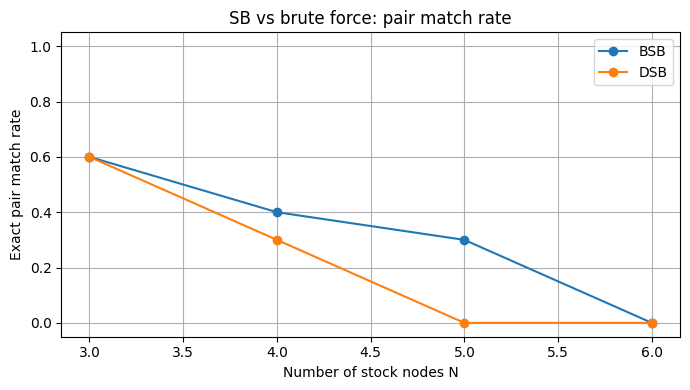

In [34]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_441[summary_441["variant"] == variant].sort_values("N")

    plt.plot(
        part["N"],
        part["exact_match_pair_rate"],
        marker="o",
        label=variant,
    )

plt.xlabel("Number of stock nodes N")
plt.ylabel("Exact pair match rate")
plt.title("SB vs brute force: pair match rate")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_04_01_pair_match_rate.png", dpi=300)
plt.show()

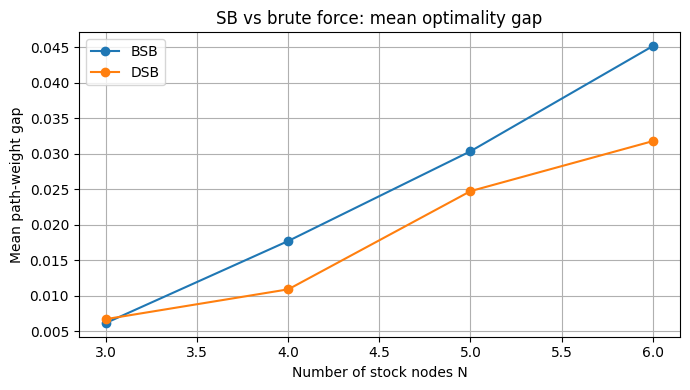

In [35]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_441[summary_441["variant"] == variant].sort_values("N")

    plt.plot(
        part["N"],
        part["mean_gap"],
        marker="o",
        label=variant,
    )

plt.xlabel("Number of stock nodes N")
plt.ylabel("Mean path-weight gap")
plt.title("SB vs brute force: mean optimality gap")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_04_01_mean_gap.png", dpi=300)
plt.show()

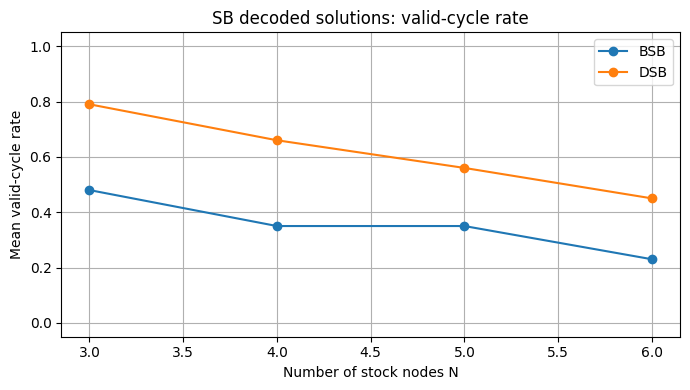

In [36]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_441[summary_441["variant"] == variant].sort_values("N")

    plt.plot(
        part["N"],
        part["mean_valid_rate"],
        marker="o",
        label=variant,
    )

plt.xlabel("Number of stock nodes N")
plt.ylabel("Mean valid-cycle rate")
plt.title("SB decoded solutions: valid-cycle rate")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_04_01_valid_rate.png", dpi=300)
plt.show()

In [37]:
results_441_exact.to_csv(
    "results_04_04_01_bruteforce_exact.csv",
    index=False,
)

results_441_comparison_raw.to_csv(
    "results_04_04_01_sb_vs_bruteforce_raw.csv",
    index=False,
)

summary_441.to_csv(
    "summary_04_04_01_sb_vs_bruteforce.csv",
    index=False,
)

summary_441_exact_runtime.to_csv(
    "summary_04_04_01_bruteforce_runtime.csv",
    index=False,
)

print("Saved 4.4.1 results.")

Saved 4.4.1 results.


## Калибровка штрафного параметра $m_p$

В QUBO-постановке полная энергия имеет вид

$$
H_{\mathrm{QUBO}} =
m_c H_{\mathrm{cost}}
+ m_p H_{\mathrm{penalty}}.
$$

Параметр $m_p$ задаёт силу штрафов за нарушение ограничений цикла. Если $m_p$ слишком мал, SB может находить низкоэнергетические, но невалидные конфигурации. Если $m_p$ слишком велик, penalty-часть начинает доминировать над исходной cost-функцией, что может ухудшить различимость хороших валидных решений.

В этом эксперименте фиксируем $m_c=1$ и подбираем $m_p$ на малых toy-графах.

In [38]:
MP_VALUES = [1, 2, 5, 10, 20, 50, 100]

N_VALUES_MP = [3, 4, 5, 6]
N_INSTANCES_MP = 10

MC_FIXED = 1.0
DT_FIXED_MP = 0.5
N_ITER_FIXED_MP = 500
N_RUNS_FIXED_MP = 10

BASE_SEED_MP = 3030

In [39]:
mp_sweep_rows = []

for N in N_VALUES_MP:
    print(f"N = {N}")

    for instance_id in range(N_INSTANCES_MP):
        print(f"  instance {instance_id}")

        toy = generate_toy_market_graph(
            N=N,
            seed=BASE_SEED_MP + 1000 * N + instance_id,
        )

        w = toy["w"]

        best_exact, all_cycles_df = brute_force_best_dummy_cycle(w)

        for mp in MP_VALUES:
            for variant in ["BSB", "DSB"]:
                best_solver, runs_df = run_sb_on_cycle_qubo(
                    w=w,
                    variant=variant,
                    n_runs=N_RUNS_FIXED_MP,
                    n_iter=N_ITER_FIXED_MP,
                    dt=DT_FIXED_MP,
                    seed=BASE_SEED_MP + 10_000 * N + 100 * instance_id + int(mp),
                    mc=MC_FIXED,
                    mp=mp,
                )

                row = compare_solver_to_exact(
                    best_solver=best_solver,
                    runs_df=runs_df,
                    best_exact=best_exact,
                    variant=variant,
                )

                row.update({
                    "N": N,
                    "instance_id": instance_id,
                    "mp": mp,
                    "mc": MC_FIXED,
                    "dt": DT_FIXED_MP,
                    "n_iter": N_ITER_FIXED_MP,
                    "n_runs": N_RUNS_FIXED_MP,
                    "exact_cycle": best_exact["cycle"],
                    "exact_short_node": best_exact["short_node"],
                    "exact_long_node": best_exact["long_node"],
                    "exact_path_nodes": best_exact["path_nodes"],
                    "exact_path_weight": best_exact["path_weight"],
                })

                mp_sweep_rows.append(row)

results_mp_sweep_raw = pd.DataFrame(mp_sweep_rows)

results_mp_sweep_raw.head()

N = 3
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
  instance 5
  instance 6
  instance 7
  instance 8
  instance 9
N = 4
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
  instance 5
  instance 6
  instance 7
  instance 8
  instance 9
N = 5
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
  instance 5
  instance 6
  instance 7
  instance 8
  instance 9
N = 6
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
  instance 5
  instance 6
  instance 7
  instance 8
  instance 9


,variant,found_valid,valid_rate,exact_path_weight,solver_path_weight,gap,same_pair,same_path,exact_cycle,solver_cycle,...,N,instance_id,mp,mc,dt,n_iter,n_runs,exact_short_node,exact_long_node,exact_path_nodes
0,BSB,True,0.6,-0.02073,-0.014068,0.006662,False,False,"[0, 2, 3, 0]","[0, 1, 2, 3, 0]",...,3,0,1,1.0,0.5,500,10,2,3,"[2, 3]"
1,DSB,True,0.8,-0.02073,-0.020730,0.000000,True,True,"[0, 2, 3, 0]","[0, 2, 3, 0]",...,3,0,1,1.0,0.5,500,10,2,3,"[2, 3]"
2,BSB,True,0.2,-0.02073,-0.006107,0.014623,False,False,"[0, 2, 3, 0]","[0, 2, 3, 1, 0]",...,3,0,2,1.0,0.5,500,10,2,3,"[2, 3]"
3,DSB,True,1.0,-0.02073,-0.020730,0.000000,True,True,"[0, 2, 3, 0]","[0, 2, 3, 0]",...,3,0,2,1.0,0.5,500,10,2,3,"[2, 3]"
4,BSB,True,0.3,-0.02073,-0.014068,0.006662,False,False,"[0, 2, 3, 0]","[0, 1, 2, 3, 0]",...,3,0,5,1.0,0.5,500,10,2,3,"[2, 3]"


In [41]:
summary_mp_sweep = (
    results_mp_sweep_raw
    .groupby(["mp", "variant"], as_index=False)
    .agg(
        found_valid_rate=("found_valid", "mean"),
        mean_valid_rate=("valid_rate", "mean"),
        exact_match_pair_rate=("same_pair", "mean"),
        exact_match_path_rate=("same_path", "mean"),
        mean_gap=("gap", "mean"),
        median_gap=("gap", "median"),
        max_gap=("gap", "max"),
        mean_runtime_ms=("mean_runtime_ms", "mean"),
        n_instances=("instance_id", "nunique"),
    )
)

summary_mp_sweep

,mp,variant,found_valid_rate,mean_valid_rate,exact_match_pair_rate,exact_match_path_rate,mean_gap,median_gap,max_gap,mean_runtime_ms,n_instances
0,1,BSB,1.000,0.4075,0.525,0.150,0.011744,0.009363,0.036630,14.887104,10
1,1,DSB,1.000,0.7050,0.400,0.200,0.014578,0.015182,0.041281,16.459042,10
2,2,BSB,1.000,0.3725,0.225,0.050,0.024533,0.022428,0.089701,15.169478,10
3,2,DSB,1.000,0.6650,0.375,0.175,0.017617,0.008306,0.086855,15.238467,10
4,5,BSB,1.000,0.3850,0.325,0.075,0.025187,0.020565,0.074671,14.713839,10
5,5,DSB,1.000,0.6675,0.425,0.175,0.021992,0.014186,0.100060,15.201432,10
6,10,BSB,0.975,0.3825,0.325,0.100,0.026042,0.014744,0.093541,14.776062,10
7,10,DSB,1.000,0.6550,0.325,0.125,0.021456,0.012473,0.114692,15.164605,10
8,20,BSB,1.000,0.3650,0.250,0.125,0.026876,0.018333,0.090721,14.852061,10
9,20,DSB,1.000,0.6650,0.225,0.075,0.020680,0.018185,0.076054,15.510932,10


In [42]:
summary_mp_sweep_by_N = (
    results_mp_sweep_raw
    .groupby(["N", "mp", "variant"], as_index=False)
    .agg(
        found_valid_rate=("found_valid", "mean"),
        mean_valid_rate=("valid_rate", "mean"),
        exact_match_pair_rate=("same_pair", "mean"),
        exact_match_path_rate=("same_path", "mean"),
        mean_gap=("gap", "mean"),
        median_gap=("gap", "median"),
        max_gap=("gap", "max"),
        mean_runtime_ms=("mean_runtime_ms", "mean"),
        n_instances=("instance_id", "nunique"),
    )
)

summary_mp_sweep_by_N.head()

,N,mp,variant,found_valid_rate,mean_valid_rate,exact_match_pair_rate,exact_match_path_rate,mean_gap,median_gap,max_gap,mean_runtime_ms,n_instances
0,3,1,BSB,1.0,0.45,0.6,0.3,0.003780,0.003517,0.008565,14.687291,10
1,3,1,DSB,1.0,0.84,0.7,0.5,0.002738,0.000364,0.012259,16.285908,10
2,3,2,BSB,1.0,0.41,0.5,0.2,0.013610,0.004995,0.089701,15.796395,10
3,3,2,DSB,1.0,0.86,0.7,0.6,0.001125,0.000000,0.003996,15.198246,10
4,3,5,BSB,1.0,0.46,0.6,0.2,0.004319,0.002916,0.013443,14.719517,10


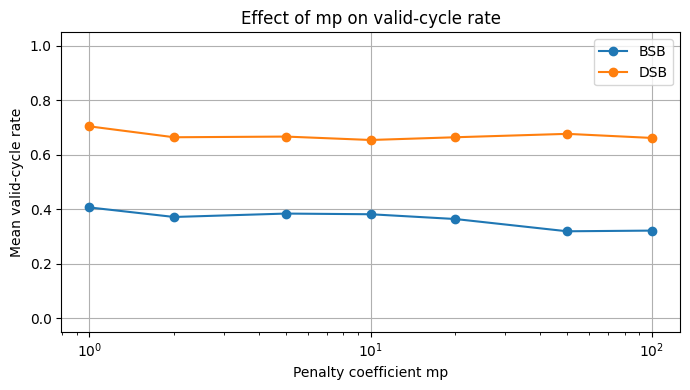

In [43]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_mp_sweep[
        summary_mp_sweep["variant"] == variant
    ].sort_values("mp")

    plt.plot(
        part["mp"],
        part["mean_valid_rate"],
        marker="o",
        label=variant,
    )

plt.xscale("log")
plt.xlabel("Penalty coefficient mp")
plt.ylabel("Mean valid-cycle rate")
plt.title("Effect of mp on valid-cycle rate")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_04_01_mp_valid_rate.png", dpi=300)
plt.show()

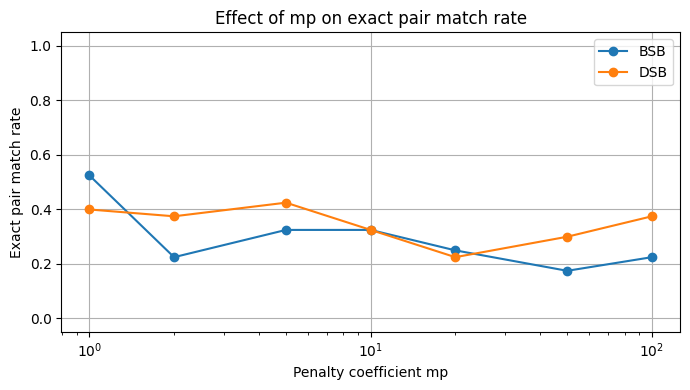

In [44]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_mp_sweep[
        summary_mp_sweep["variant"] == variant
    ].sort_values("mp")

    plt.plot(
        part["mp"],
        part["exact_match_pair_rate"],
        marker="o",
        label=variant,
    )

plt.xscale("log")
plt.xlabel("Penalty coefficient mp")
plt.ylabel("Exact pair match rate")
plt.title("Effect of mp on exact pair match rate")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_04_01_mp_pair_match_rate.png", dpi=300)
plt.show()

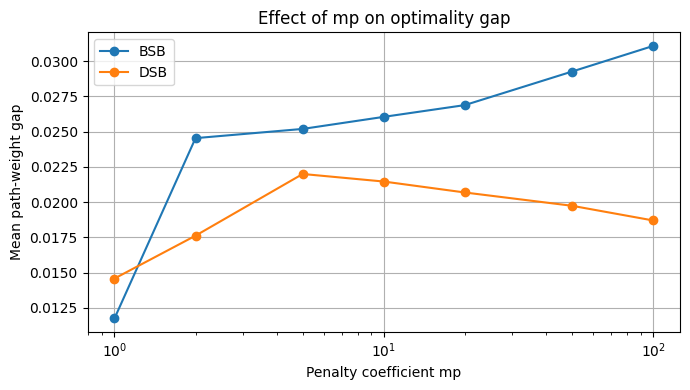

In [45]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_mp_sweep[
        summary_mp_sweep["variant"] == variant
    ].sort_values("mp")

    plt.plot(
        part["mp"],
        part["mean_gap"],
        marker="o",
        label=variant,
    )

plt.xscale("log")
plt.xlabel("Penalty coefficient mp")
plt.ylabel("Mean path-weight gap")
plt.title("Effect of mp on optimality gap")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_04_01_mp_mean_gap.png", dpi=300)
plt.show()

In [46]:
mp_selection = summary_mp_sweep.copy()

# Нормируем gap: чем меньше, тем лучше.
# Если gap везде примерно 0, защита от деления на 0.
gap_min = mp_selection["mean_gap"].min()
gap_max = mp_selection["mean_gap"].max()

if gap_max > gap_min + 1e-12:
    mp_selection["gap_score"] = 1.0 - (
        (mp_selection["mean_gap"] - gap_min) / (gap_max - gap_min)
    )
else:
    mp_selection["gap_score"] = 1.0

mp_selection["selection_score"] = (
    0.4 * mp_selection["mean_valid_rate"]
    + 0.4 * mp_selection["exact_match_pair_rate"]
    + 0.2 * mp_selection["gap_score"]
)

mp_selection.sort_values(
    ["variant", "selection_score"],
    ascending=[True, False],
)

,mp,variant,found_valid_rate,mean_valid_rate,exact_match_pair_rate,exact_match_path_rate,mean_gap,median_gap,max_gap,mean_runtime_ms,n_instances,gap_score,selection_score
0,1,BSB,1.000,0.4075,0.525,0.150,0.011744,0.009363,0.036630,14.887104,10,1.000000,0.573000
4,5,BSB,1.000,0.3850,0.325,0.075,0.025187,0.020565,0.074671,14.713839,10,0.304415,0.344883
6,10,BSB,0.975,0.3825,0.325,0.100,0.026042,0.014744,0.093541,14.776062,10,0.260161,0.335032
2,2,BSB,1.000,0.3725,0.225,0.050,0.024533,0.022428,0.089701,15.169478,10,0.338229,0.306646
8,20,BSB,1.000,0.3650,0.250,0.125,0.026876,0.018333,0.090721,14.852061,10,0.216986,0.289397
12,100,BSB,0.925,0.3225,0.225,0.025,0.031070,0.025353,0.099902,14.726498,10,0.000000,0.219000
10,50,BSB,0.925,0.3200,0.175,0.075,0.029254,0.016983,0.149307,14.862248,10,0.093963,0.216793
1,1,DSB,1.000,0.7050,0.400,0.200,0.014578,0.015182,0.041281,16.459042,10,0.853368,0.612674
3,2,DSB,1.000,0.6650,0.375,0.175,0.017617,0.008306,0.086855,15.238467,10,0.696138,0.555228
13,100,DSB,1.000,0.6625,0.375,0.150,0.018697,0.016230,0.084338,15.250506,10,0.640231,0.543046


In [47]:
mp_selection_global = (
    mp_selection
    .groupby("mp", as_index=False)
    .agg(
        mean_valid_rate=("mean_valid_rate", "mean"),
        exact_match_pair_rate=("exact_match_pair_rate", "mean"),
        mean_gap=("mean_gap", "mean"),
        selection_score=("selection_score", "mean"),
    )
    .sort_values("selection_score", ascending=False)
)

mp_selection_global

,mp,mean_valid_rate,exact_match_pair_rate,mean_gap,selection_score
0,1,0.55625,0.4625,0.013161,0.592837
2,5,0.52625,0.3750,0.023589,0.437915
1,2,0.51875,0.3000,0.021075,0.430937
3,10,0.51875,0.3250,0.023749,0.413263
6,100,0.49250,0.3000,0.024883,0.381023
4,20,0.51500,0.2375,0.023778,0.376463
5,50,0.49875,0.2375,0.024496,0.362537


In [48]:
results_mp_sweep_raw.to_csv(
    "results_04_04_01_mp_sweep_raw.csv",
    index=False,
)

summary_mp_sweep.to_csv(
    "summary_04_04_01_mp_sweep.csv",
    index=False,
)

summary_mp_sweep_by_N.to_csv(
    "summary_04_04_01_mp_sweep_by_N.csv",
    index=False,
)

mp_selection_global.to_csv(
    "selection_04_04_01_mp_global.csv",
    index=False,
)

print("Saved mp sweep results.")

Saved mp sweep results.


### Промежуточный вывод по калибровке $m_p$

Калибровка penalty-параметра $m_p$ показала, что качество SB-решения constrained QUBO существенно зависит от относительной силы штрафов.

При малых значениях $m_p$ ограничения цикла недостаточно сильно влияют на энергию, поэтому часть декодированных решений оказывается невалидной. При чрезмерно больших значениях $m_p$ penalty-часть начинает доминировать над cost-частью, что может ухудшить способность алгоритма различать валидные циклы по их рыночному весу.

Поэтому для дальнейших экспериментов $m_p$ выбирается не как максимально возможный штраф, а как компромисс между:

- долей валидных решений;
- частотой совпадения с exact-парой;
- средним optimality gap.

In [49]:
mc = 1.0
mp = 1.0
dt = 0.5
n_iter = 500

## Калибровка числа запусков `n_runs` для QUBO-задачи

После калибровки penalty-параметра было выбрано значение

$$
m_p = 1.
$$

Теперь фиксируем параметры QUBO и SB-динамики:

$$
m_c = 1,\qquad m_p = 1,\qquad dt = 0.5,\qquad n_{\mathrm{iter}} = 500.
$$

Далее варьируется только число независимых запусков `n_runs`.

Поскольку SB является эвристическим multi-start методом, увеличение `n_runs` должно повышать вероятность того, что хотя бы один запуск найдёт оптимальный dummy-cycle.

In [50]:
N_RUNS_VALUES_QUBO = [10, 20, 50, 100]

N_VALUES_NR_QUBO = [3, 4, 5, 6]
N_INSTANCES_NR_QUBO = 10

MC_FIXED_QUBO = 1.0
MP_FIXED_QUBO = 1.0

DT_FIXED_QUBO = 0.5
N_ITER_FIXED_QUBO = 500

BASE_SEED_NR_QUBO = 4040

In [51]:
n_runs_qubo_rows = []

for N in N_VALUES_NR_QUBO:
    print(f"N = {N}")

    for instance_id in range(N_INSTANCES_NR_QUBO):
        print(f"  instance {instance_id}")

        toy = generate_toy_market_graph(
            N=N,
            seed=BASE_SEED_NR_QUBO + 1000 * N + instance_id,
        )

        w = toy["w"]

        best_exact, all_cycles_df = brute_force_best_dummy_cycle(w)

        for n_runs in N_RUNS_VALUES_QUBO:
            for variant in ["BSB", "DSB"]:
                best_solver, runs_df = run_sb_on_cycle_qubo(
                    w=w,
                    variant=variant,
                    n_runs=n_runs,
                    n_iter=N_ITER_FIXED_QUBO,
                    dt=DT_FIXED_QUBO,
                    seed=BASE_SEED_NR_QUBO + 10_000 * N + 100 * instance_id,
                    mc=MC_FIXED_QUBO,
                    mp=MP_FIXED_QUBO,
                )

                row = compare_solver_to_exact(
                    best_solver=best_solver,
                    runs_df=runs_df,
                    best_exact=best_exact,
                    variant=variant,
                )

                row.update({
                    "N": N,
                    "instance_id": instance_id,
                    "n_runs": n_runs,
                    "mc": MC_FIXED_QUBO,
                    "mp": MP_FIXED_QUBO,
                    "dt": DT_FIXED_QUBO,
                    "n_iter": N_ITER_FIXED_QUBO,
                    "exact_cycle": best_exact["cycle"],
                    "exact_short_node": best_exact["short_node"],
                    "exact_long_node": best_exact["long_node"],
                    "exact_path_nodes": best_exact["path_nodes"],
                    "exact_path_weight": best_exact["path_weight"],
                })

                n_runs_qubo_rows.append(row)

results_n_runs_qubo_raw = pd.DataFrame(n_runs_qubo_rows)

results_n_runs_qubo_raw.head()

N = 3
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
  instance 5
  instance 6
  instance 7
  instance 8
  instance 9
N = 4
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
  instance 5
  instance 6
  instance 7
  instance 8
  instance 9
N = 5
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
  instance 5
  instance 6
  instance 7
  instance 8
  instance 9
N = 6
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
  instance 5
  instance 6
  instance 7
  instance 8
  instance 9


,variant,found_valid,valid_rate,exact_path_weight,solver_path_weight,gap,same_pair,same_path,exact_cycle,solver_cycle,...,N,instance_id,n_runs,mc,mp,dt,n_iter,exact_short_node,exact_long_node,exact_path_nodes
0,BSB,True,0.70,0.000535,0.004228,0.003693,True,False,"[0, 2, 1, 0]","[0, 2, 3, 1, 0]",...,3,0,10,1.0,1.0,0.5,500,2,1,"[2, 1]"
1,DSB,True,0.70,0.000535,0.000535,0.000000,True,True,"[0, 2, 1, 0]","[0, 2, 1, 0]",...,3,0,10,1.0,1.0,0.5,500,2,1,"[2, 1]"
2,BSB,True,0.60,0.000535,0.004228,0.003693,True,False,"[0, 2, 1, 0]","[0, 2, 3, 1, 0]",...,3,0,20,1.0,1.0,0.5,500,2,1,"[2, 1]"
3,DSB,True,0.75,0.000535,0.000535,0.000000,True,True,"[0, 2, 1, 0]","[0, 2, 1, 0]",...,3,0,20,1.0,1.0,0.5,500,2,1,"[2, 1]"
4,BSB,True,0.48,0.000535,0.002665,0.002129,False,False,"[0, 2, 1, 0]","[0, 1, 3, 0]",...,3,0,50,1.0,1.0,0.5,500,2,1,"[2, 1]"


In [52]:
summary_n_runs_qubo = (
    results_n_runs_qubo_raw
    .groupby(["n_runs", "variant"], as_index=False)
    .agg(
        found_valid_rate=("found_valid", "mean"),
        mean_valid_rate=("valid_rate", "mean"),
        exact_match_pair_rate=("same_pair", "mean"),
        exact_match_path_rate=("same_path", "mean"),
        mean_gap=("gap", "mean"),
        median_gap=("gap", "median"),
        max_gap=("gap", "max"),
        mean_runtime_ms=("mean_runtime_ms", "mean"),
        n_instances=("instance_id", "nunique"),
    )
)

summary_n_runs_qubo

,n_runs,variant,found_valid_rate,mean_valid_rate,exact_match_pair_rate,exact_match_path_rate,mean_gap,median_gap,max_gap,mean_runtime_ms,n_instances
0,10,BSB,1.0,0.40750,0.300,0.075,0.015282,0.014133,0.054987,15.473497,10
1,10,DSB,1.0,0.66500,0.425,0.225,0.015147,0.013311,0.060051,16.648567,10
2,20,BSB,1.0,0.39750,0.350,0.125,0.009687,0.007661,0.036733,15.558509,10
3,20,DSB,1.0,0.68500,0.425,0.225,0.012018,0.010327,0.053654,15.887467,10
4,50,BSB,1.0,0.41900,0.450,0.250,0.006294,0.004828,0.021607,15.361775,10
5,50,DSB,1.0,0.68650,0.550,0.350,0.007911,0.005754,0.032152,15.571997,10
6,100,BSB,1.0,0.41275,0.550,0.350,0.003874,0.001698,0.015841,15.115732,10
7,100,DSB,1.0,0.68425,0.700,0.500,0.004027,0.000103,0.028611,15.597265,10


In [53]:
summary_n_runs_qubo_fixed = (
    results_n_runs_qubo_raw
    .assign(graph_id=lambda df: df["N"].astype(str) + "_" + df["instance_id"].astype(str))
    .groupby(["n_runs", "variant"], as_index=False)
    .agg(
        found_valid_rate=("found_valid", "mean"),
        mean_valid_rate=("valid_rate", "mean"),
        exact_match_pair_rate=("same_pair", "mean"),
        exact_match_path_rate=("same_path", "mean"),
        mean_gap=("gap", "mean"),
        median_gap=("gap", "median"),
        max_gap=("gap", "max"),
        mean_runtime_ms_per_run=("mean_runtime_ms", "mean"),
        n_graphs=("graph_id", "nunique"),
    )
)

summary_n_runs_qubo_fixed["estimated_total_runtime_ms"] = (
    summary_n_runs_qubo_fixed["mean_runtime_ms_per_run"]
    * summary_n_runs_qubo_fixed["n_runs"]
)

summary_n_runs_qubo_fixed

,n_runs,variant,found_valid_rate,mean_valid_rate,exact_match_pair_rate,exact_match_path_rate,mean_gap,median_gap,max_gap,mean_runtime_ms_per_run,n_graphs,estimated_total_runtime_ms
0,10,BSB,1.0,0.40750,0.300,0.075,0.015282,0.014133,0.054987,15.473497,40,154.734975
1,10,DSB,1.0,0.66500,0.425,0.225,0.015147,0.013311,0.060051,16.648567,40,166.485670
2,20,BSB,1.0,0.39750,0.350,0.125,0.009687,0.007661,0.036733,15.558509,40,311.170185
3,20,DSB,1.0,0.68500,0.425,0.225,0.012018,0.010327,0.053654,15.887467,40,317.749337
4,50,BSB,1.0,0.41900,0.450,0.250,0.006294,0.004828,0.021607,15.361775,40,768.088770
5,50,DSB,1.0,0.68650,0.550,0.350,0.007911,0.005754,0.032152,15.571997,40,778.599858
6,100,BSB,1.0,0.41275,0.550,0.350,0.003874,0.001698,0.015841,15.115732,40,1511.573195
7,100,DSB,1.0,0.68425,0.700,0.500,0.004027,0.000103,0.028611,15.597265,40,1559.726472


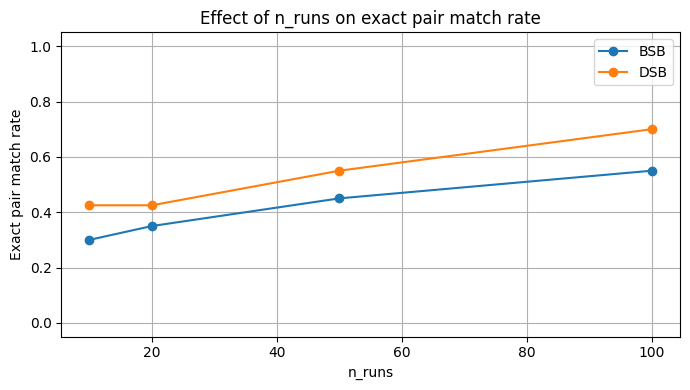

In [54]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_n_runs_qubo[
        summary_n_runs_qubo["variant"] == variant
    ].sort_values("n_runs")

    plt.plot(
        part["n_runs"],
        part["exact_match_pair_rate"],
        marker="o",
        label=variant,
    )

plt.xlabel("n_runs")
plt.ylabel("Exact pair match rate")
plt.title("Effect of n_runs on exact pair match rate")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_04_01_n_runs_pair_match_rate.png", dpi=300)
plt.show()

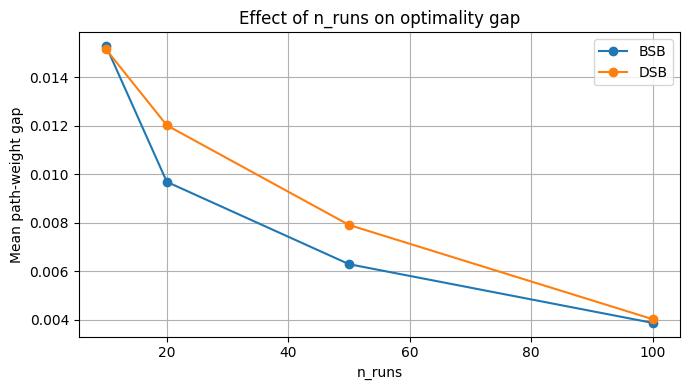

In [55]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_n_runs_qubo[
        summary_n_runs_qubo["variant"] == variant
    ].sort_values("n_runs")

    plt.plot(
        part["n_runs"],
        part["mean_gap"],
        marker="o",
        label=variant,
    )

plt.xlabel("n_runs")
plt.ylabel("Mean path-weight gap")
plt.title("Effect of n_runs on optimality gap")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_04_01_n_runs_mean_gap.png", dpi=300)
plt.show()

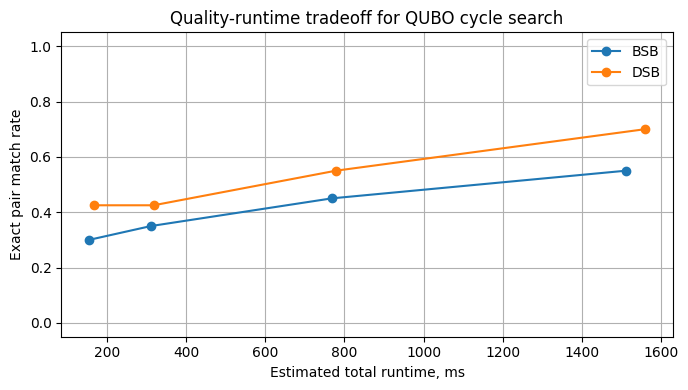

In [56]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_n_runs_qubo_fixed[
        summary_n_runs_qubo_fixed["variant"] == variant
    ].sort_values("estimated_total_runtime_ms")

    plt.plot(
        part["estimated_total_runtime_ms"],
        part["exact_match_pair_rate"],
        marker="o",
        label=variant,
    )

plt.xlabel("Estimated total runtime, ms")
plt.ylabel("Exact pair match rate")
plt.title("Quality-runtime tradeoff for QUBO cycle search")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_04_01_n_runs_quality_runtime_tradeoff.png", dpi=300)
plt.show()

In [57]:
nr_selection = summary_n_runs_qubo.copy()

gap_min = nr_selection["mean_gap"].min()
gap_max = nr_selection["mean_gap"].max()

if gap_max > gap_min + 1e-12:
    nr_selection["gap_score"] = 1.0 - (
        (nr_selection["mean_gap"] - gap_min) / (gap_max - gap_min)
    )
else:
    nr_selection["gap_score"] = 1.0

runtime_min = nr_selection["mean_runtime_ms"].min()
runtime_max = nr_selection["mean_runtime_ms"].max()

if runtime_max > runtime_min + 1e-12:
    nr_selection["runtime_score"] = 1.0 - (
        (nr_selection["mean_runtime_ms"] - runtime_min) / (runtime_max - runtime_min)
    )
else:
    nr_selection["runtime_score"] = 1.0

nr_selection["selection_score"] = (
    0.45 * nr_selection["exact_match_pair_rate"]
    + 0.35 * nr_selection["gap_score"]
    + 0.20 * nr_selection["runtime_score"]
)

nr_selection.sort_values(
    ["variant", "selection_score"],
    ascending=[True, False],
)

,n_runs,variant,found_valid_rate,mean_valid_rate,exact_match_pair_rate,exact_match_path_rate,mean_gap,median_gap,max_gap,mean_runtime_ms,n_instances,gap_score,runtime_score,selection_score
6,100,BSB,1.0,0.41275,0.550,0.350,0.003874,0.001698,0.015841,15.115732,10,1.000000,1.000000,0.797500
4,50,BSB,1.0,0.41900,0.450,0.250,0.006294,0.004828,0.021607,15.361775,10,0.787853,0.839485,0.646146
2,20,BSB,1.0,0.39750,0.350,0.125,0.009687,0.007661,0.036733,15.558509,10,0.490402,0.711138,0.471368
0,10,BSB,1.0,0.40750,0.300,0.075,0.015282,0.014133,0.054987,15.473497,10,0.000000,0.766599,0.288320
7,100,DSB,1.0,0.68425,0.700,0.500,0.004027,0.000103,0.028611,15.597265,10,0.986577,0.685855,0.797473
5,50,DSB,1.0,0.68650,0.550,0.350,0.007911,0.005754,0.032152,15.571997,10,0.646075,0.702339,0.614094
3,20,DSB,1.0,0.68500,0.425,0.225,0.012018,0.010327,0.053654,15.887467,10,0.286102,0.496531,0.390692
1,10,DSB,1.0,0.66500,0.425,0.225,0.015147,0.013311,0.060051,16.648567,10,0.011835,0.000000,0.195392


In [58]:
nr_selection_global = (
    nr_selection
    .groupby("n_runs", as_index=False)
    .agg(
        exact_match_pair_rate=("exact_match_pair_rate", "mean"),
        mean_gap=("mean_gap", "mean"),
        mean_runtime_ms=("mean_runtime_ms", "mean"),
        selection_score=("selection_score", "mean"),
    )
    .sort_values("selection_score", ascending=False)
)

nr_selection_global

,n_runs,exact_match_pair_rate,mean_gap,mean_runtime_ms,selection_score
3,100,0.6250,0.003950,15.356498,0.797486
2,50,0.5000,0.007103,15.466886,0.630120
1,20,0.3875,0.010853,15.722988,0.431030
0,10,0.3625,0.015214,16.061032,0.241856


In [61]:
results_n_runs_qubo_raw.to_csv(
    "results_04_04_01_n_runs_qubo_raw.csv",
    index=False,
)

summary_n_runs_qubo.to_csv(
    "summary_04_04_01_n_runs_qubo.csv",
    index=False,
)

summary_n_runs_qubo_fixed.to_csv(
    "summary_04_04_01_n_runs_qubo_by_N.csv",
    index=False,
)

nr_selection_global.to_csv(
    "selection_04_04_01_n_runs_global.csv",
    index=False,
)

print("Saved n_runs QUBO sweep results.")

Saved n_runs QUBO sweep results.


# 4.4.2. MILP / HiGHS для точного решения задачи цикла

В этом блоке задача поиска торговой пары формулируется как бинарная линейная оптимизационная модель.

Переменная

$$
b_{ij} \in \{0,1\}
$$

равна единице, если напрвленное ребро $i \to j$ входит в выбранный цикл.

Целевая функция:

$$
\min \sum_{i,j} w_{ij} b_{ij}.
$$

Ограничения обеспечивают, что выбранные рёбра образуют один цикл, проходящий через dummy node:

$$
0 \to \text{short} \to \ldots \to \text{long} \to 0.
$$

В отличие от QUBO, где ограничения добавляются в objective через penalty, MILP задаёт ограничения явно.

In [62]:
from scipy.optimize import milp, LinearConstraint, Bounds
from scipy.sparse import lil_matrix

from qubo_cycle import build_var_map

In [ ]:
def solve_cycle_milp_highs(w, verbose=False):
    """
    Exact MILP solver для задачи:

        min sum_{i,j} w[i,j] b[i,j]

    где выбранные b[i,j] должны образовывать один directed cycle через dummy node 0.

    Используются:
    - flow balance;
    - dummy out-degree = 1;
    - dummy in-degree = 1;
    - in/out degree <= 1 для stock nodes;
    - запрет subtours через subset constraints.
    """
    w = np.asarray(w, dtype=float)
    N = w.shape[0] - 1

    var_map = build_var_map(N)
    edges = var_map.edges
    M = len(edges)

    c = np.array([w[i, j] for (i, j) in edges], dtype=float)

    rows = []
    lbs = []
    ubs = []

    def add_constraint(coeffs, lb, ub):
        rows.append(coeffs)
        lbs.append(lb)
        ubs.append(ub)

    # 1. Flow balance для всех nodes:
    # sum_j b[i,j] - sum_j b[j,i] = 0
    for node in range(N + 1):
        coeffs = {}

        for u, (i, j) in enumerate(edges):
            if i == node:
                coeffs[u] = coeffs.get(u, 0.0) + 1.0
            if j == node:
                coeffs[u] = coeffs.get(u, 0.0) - 1.0

        add_constraint(coeffs, 0.0, 0.0)

    # 2. Dummy out - degree = 1
    coeffs = {
        u: 1.0
        for u, (i, j) in enumerate(edges)
        if i == 0
    }
    add_constraint(coeffs, 1.0, 1.0)

    # 3. Dummy in - degree = 1
    coeffs = {
        u: 1.0
        for u, (i, j) in enumerate(edges)
        if j == 0
    }
    add_constraint(coeffs, 1.0, 1.0)

    # 4. Для реальных вершин: out-degree <= 1 и in-degree <= 1
    for node in range(1, N + 1):
        coeffs_out = {
            u: 1.0
            for u, (i, j) in enumerate(edges)
            if i == node
        }
        add_constraint(coeffs_out, 0.0, 1.0)

        coeffs_in = {
            u: 1.0
            for u, (i, j) in enumerate(edges)
            if j == node
        }
        add_constraint(coeffs_in, 0.0, 1.0)

    # 5. Запрещаем тривиальный цикл 0 -> a -> 0:
    # нужно хотя бы одно stock-stock ребро.
    coeffs = {
        u: 1.0
        for u, (i, j) in enumerate(edges)
        if i != 0 and j != 0
    }
    add_constraint(coeffs, 1.0, np.inf)

    # 6. Subtour elimination:
    # для любого подмножества stock nodes S:
    # sum_{i in S, j in S} b[i,j] <= |S| - 1
    stock_nodes = list(range(1, N + 1))

    for r in range(2, N + 1):
        for S_tuple in itertools.combinations(stock_nodes, r):
            S = set(S_tuple)

            coeffs = {
                u: 1.0
                for u, (i, j) in enumerate(edges)
                if i in S and j in S
            }

            add_constraint(coeffs, 0.0, r - 1.0)

    # Собираем sparse matrix A
    A = lil_matrix((len(rows), M), dtype=float)

    for row_idx, coeffs in enumerate(rows):
        for u, val in coeffs.items():
            A[row_idx, u] = val

    constraints = LinearConstraint(
        A.tocsr(),
        lb=np.array(lbs, dtype=float),
        ub=np.array(ubs, dtype=float),
    )

    bounds = Bounds(
        lb=np.zeros(M),
        ub=np.ones(M),
    )

    integrality = np.ones(M, dtype=int)

    start = time.perf_counter()

    result = milp(
        c=c,
        integrality=integrality,
        bounds=bounds,
        constraints=constraints,
        options={
            "disp": verbose,
        },
    )

    runtime_sec = time.perf_counter() - start

    if not result.success:
        return {
            "success": False,
            "message": result.message,
            "runtime_sec": runtime_sec,
        }

    z = np.rint(result.x).astype(int)
    selected_edges = decode_edges_from_z(z, var_map)

    ok, cycle = verify_single_dummy_cycle(
        selected_edges=selected_edges,
        N=N,
    )

    if ok:
        short_node, long_node, path_nodes, pw = extract_pair_and_weight(
            cycle=cycle,
            w=w,
        )
    else:
        short_node, long_node, path_nodes, pw = None, None, None, np.nan

    return {
        "success": True,
        "message": result.message,
        "objective": float(result.fun),
        "runtime_sec": runtime_sec,
        "z": z,
        "selected_edges": selected_edges,
        "is_valid_dummy_cycle": ok,
        "cycle": cycle,
        "short_node": short_node,
        "long_node": long_node,
        "path_nodes": path_nodes,
        "path_weight": pw,
    }

In [64]:
toy_milp = generate_toy_market_graph(N=5, seed=123)
w_milp = toy_milp["w"]

best_exact_milp, all_cycles_milp_df = brute_force_best_dummy_cycle(w_milp)

milp_solution = solve_cycle_milp_highs(w_milp)

best_exact_milp, milp_solution

({'cycle': [0, 1, 5, 2, 0],
  'selected_edges': [(0, 1), (1, 5), (5, 2), (2, 0)],
  'short_node': 1,
  'long_node': 2,
  'path_nodes': [1, 5, 2],
  'path_length': 3,
  'path_weight': -0.03834920095713669},
 {'success': True,
  'message': 'Optimization terminated successfully. (HiGHS Status 7: Optimal)',
  'objective': -0.03834920095713669,
  'runtime_sec': 0.023366699999314733,
  'z': array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 1, 0, 0]),
  'selected_edges': [(0, 1), (1, 5), (2, 0), (5, 2)],
  'is_valid_dummy_cycle': True,
  'cycle': [0, 1, 5, 2, 0],
  'short_node': 1,
  'long_node': 2,
  'path_nodes': [1, 5, 2],
  'path_weight': -0.03834920095713669})

In [65]:
assert milp_solution["success"]
assert milp_solution["is_valid_dummy_cycle"]

assert np.isclose(
    milp_solution["path_weight"],
    best_exact_milp["path_weight"],
)

assert milp_solution["short_node"] == best_exact_milp["short_node"]
assert milp_solution["long_node"] == best_exact_milp["long_node"]

print("MILP solution matches brute force exact solution.")

MILP solution matches brute force exact solution.


In [66]:
N_VALUES_MILP_SMALL = [3, 4, 5, 6, 7, 8]
N_INSTANCES_MILP_SMALL = 10
BASE_SEED_MILP = 5050

milp_vs_bruteforce_rows = []

for N in N_VALUES_MILP_SMALL:
    print(f"N = {N}")

    for instance_id in range(N_INSTANCES_MILP_SMALL):
        toy = generate_toy_market_graph(
            N=N,
            seed=BASE_SEED_MILP + 1000 * N + instance_id,
        )

        w = toy["w"]

        start_bf = time.perf_counter()
        best_bf, all_cycles_df = brute_force_best_dummy_cycle(w)
        bf_runtime_sec = time.perf_counter() - start_bf

        milp_sol = solve_cycle_milp_highs(w)

        milp_vs_bruteforce_rows.append({
            "N": N,
            "instance_id": instance_id,
            "bruteforce_path_weight": best_bf["path_weight"],
            "milp_path_weight": milp_sol["path_weight"],
            "gap": milp_sol["path_weight"] - best_bf["path_weight"],
            "same_pair": (
                milp_sol["short_node"] == best_bf["short_node"]
                and milp_sol["long_node"] == best_bf["long_node"]
            ),
            "same_path": milp_sol["path_nodes"] == best_bf["path_nodes"],
            "milp_success": milp_sol["success"],
            "milp_valid": milp_sol["is_valid_dummy_cycle"],
            "n_valid_cycles": len(all_cycles_df),
            "bruteforce_runtime_ms": 1000 * bf_runtime_sec,
            "milp_runtime_ms": 1000 * milp_sol["runtime_sec"],
            "bruteforce_cycle": best_bf["cycle"],
            "milp_cycle": milp_sol["cycle"],
        })

results_442_milp_vs_bruteforce = pd.DataFrame(milp_vs_bruteforce_rows)

results_442_milp_vs_bruteforce.head()

N = 3
N = 4
N = 5
N = 6
N = 7
N = 8


,N,instance_id,bruteforce_path_weight,milp_path_weight,gap,same_pair,same_path,milp_success,milp_valid,n_valid_cycles,bruteforce_runtime_ms,milp_runtime_ms,bruteforce_cycle,milp_cycle
0,3,0,-0.035795,-0.035795,0.0,True,True,True,True,12,2.3238,3.1683,"[0, 3, 1, 0]","[0, 3, 1, 0]"
1,3,1,-0.024377,-0.024377,0.0,True,True,True,True,12,1.0824,2.2303,"[0, 1, 3, 0]","[0, 1, 3, 0]"
2,3,2,-0.027967,-0.027967,0.0,True,True,True,True,12,1.0025,1.8887,"[0, 2, 3, 0]","[0, 2, 3, 0]"
3,3,3,-0.046931,-0.046931,0.0,True,True,True,True,12,0.8440,1.7645,"[0, 1, 2, 0]","[0, 1, 2, 0]"
4,3,4,-0.060220,-0.060220,0.0,True,True,True,True,12,0.8337,1.8847,"[0, 3, 1, 0]","[0, 3, 1, 0]"


In [67]:
summary_442_milp_vs_bruteforce = (
    results_442_milp_vs_bruteforce
    .groupby("N", as_index=False)
    .agg(
        milp_success_rate=("milp_success", "mean"),
        milp_valid_rate=("milp_valid", "mean"),
        same_pair_rate=("same_pair", "mean"),
        same_path_rate=("same_path", "mean"),
        mean_gap=("gap", "mean"),
        max_abs_gap=("gap", lambda x: np.max(np.abs(x))),
        mean_n_valid_cycles=("n_valid_cycles", "mean"),
        mean_bruteforce_runtime_ms=("bruteforce_runtime_ms", "mean"),
        mean_milp_runtime_ms=("milp_runtime_ms", "mean"),
        n_instances=("instance_id", "nunique"),
    )
)

summary_442_milp_vs_bruteforce

,N,milp_success_rate,milp_valid_rate,same_pair_rate,same_path_rate,mean_gap,max_abs_gap,mean_n_valid_cycles,mean_bruteforce_runtime_ms,mean_milp_runtime_ms,n_instances
0,3,1.0,1.0,1.0,1.0,0.0,0.0,12.0,1.14761,2.22335,10
1,4,1.0,1.0,1.0,1.0,0.0,0.0,60.0,1.27375,2.56751,10
2,5,1.0,1.0,1.0,1.0,0.0,0.0,320.0,2.55912,3.25708,10
3,6,1.0,1.0,1.0,1.0,0.0,0.0,1950.0,19.98325,5.70689,10
4,7,1.0,1.0,1.0,1.0,0.0,0.0,13692.0,139.58347,13.27740,10
5,8,1.0,1.0,1.0,1.0,0.0,0.0,109592.0,1477.74768,18.84469,10


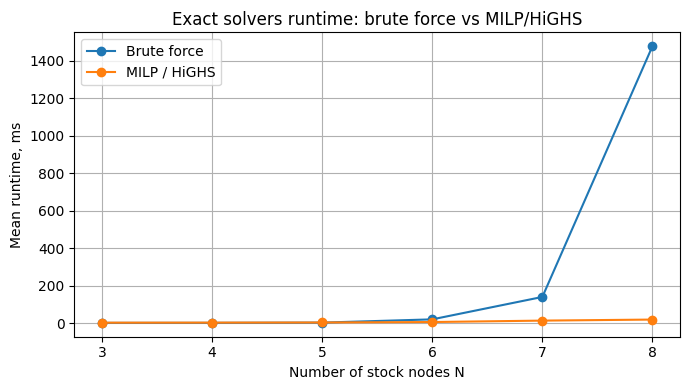

In [68]:
plt.figure(figsize=(7, 4))

plt.plot(
    summary_442_milp_vs_bruteforce["N"],
    summary_442_milp_vs_bruteforce["mean_bruteforce_runtime_ms"],
    marker="o",
    label="Brute force",
)

plt.plot(
    summary_442_milp_vs_bruteforce["N"],
    summary_442_milp_vs_bruteforce["mean_milp_runtime_ms"],
    marker="o",
    label="MILP / HiGHS",
)

plt.xlabel("Number of stock nodes N")
plt.ylabel("Mean runtime, ms")
plt.title("Exact solvers runtime: brute force vs MILP/HiGHS")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_04_02_bruteforce_vs_milp_runtime.png", dpi=300)
plt.show()

In [69]:
results_442_milp_vs_bruteforce.to_csv(
    "results_04_04_02_milp_vs_bruteforce.csv",
    index=False,
)

summary_442_milp_vs_bruteforce.to_csv(
    "summary_04_04_02_milp_vs_bruteforce.csv",
    index=False,
)

print("Saved MILP vs brute force results.")

Saved MILP vs brute force results.


## Сравнение SB с MILP / HiGHS на более крупных графах

После проверки, что MILP / HiGHS совпадает с brute force на малых графах, можно использовать MILP как точный baseline для более крупных toy market graphs.

В этом эксперименте сравниваются:

- exact-решение MILP / HiGHS;
- bSB;
- dSB.

Для SB используются параметры, выбранные после калибровки QUBO-задачи:

$$
m_c = 1,\qquad
m_p = 1,\qquad
dt = 0.5,\qquad
n_{\mathrm{iter}} = 500,\qquad
n_{\mathrm{runs}} = 100.
$$

Основные метрики:

- совпадение найденной пары с MILP;
- совпадение полного пути с MILP;
- optimality gap по path weight;
- доля валидных decoded cycles;
- время работы.

In [70]:
N_VALUES_SB_MILP = [6, 8, 10, 12]
N_INSTANCES_SB_MILP = 10

MC_SB_MILP = 1.0
MP_SB_MILP = 1.0

DT_SB_MILP = 0.5
N_ITER_SB_MILP = 500
N_RUNS_SB_MILP = 100

BASE_SEED_SB_MILP = 6060

In [ ]:
def compare_solver_to_milp(best_solver, runs_df, milp_solution, variant):
    """
    Сравнивает лучшее валидное SB-решение с точным MILP baseline.
    """
    valid_rate = runs_df["ok"].mean()
    mean_runtime_ms_per_run = 1000 * runs_df["runtime_sec"].mean()
    total_runtime_ms = mean_runtime_ms_per_run * len(runs_df)

    if best_solver is None:
        return {
            "variant": variant,
            "found_valid": False,
            "valid_rate": valid_rate,
            "milp_path_weight": milp_solution["path_weight"],
            "solver_path_weight": np.nan,
            "gap": np.nan,
            "same_pair": False,
            "same_path": False,
            "mean_runtime_ms_per_run": mean_runtime_ms_per_run,
            "total_runtime_ms": total_runtime_ms,
        }

    same_pair = (
        best_solver["short_node"] == milp_solution["short_node"]
        and best_solver["long_node"] == milp_solution["long_node"]
    )

    same_path = best_solver["path_nodes"] == milp_solution["path_nodes"]

    return {
        "variant": variant,
        "found_valid": True,
        "valid_rate": valid_rate,
        "milp_path_weight": milp_solution["path_weight"],
        "solver_path_weight": best_solver["path_weight"],
        "gap": best_solver["path_weight"] - milp_solution["path_weight"],
        "same_pair": same_pair,
        "same_path": same_path,
        "milp_cycle": milp_solution["cycle"],
        "solver_cycle": best_solver["cycle"],
        "mean_runtime_ms_per_run": mean_runtime_ms_per_run,
        "total_runtime_ms": total_runtime_ms,
    }

In [72]:
sb_vs_milp_rows = []
milp_baseline_rows = []

for N in N_VALUES_SB_MILP:
    print(f"N = {N}")

    for instance_id in range(N_INSTANCES_SB_MILP):
        print(f"  instance {instance_id}")

        toy = generate_toy_market_graph(
            N=N,
            seed=BASE_SEED_SB_MILP + 1000 * N + instance_id,
        )

        w = toy["w"]

        milp_solution = solve_cycle_milp_highs(w)

        assert milp_solution["success"]
        assert milp_solution["is_valid_dummy_cycle"]

        milp_baseline_rows.append({
            "N": N,
            "instance_id": instance_id,
            "milp_path_weight": milp_solution["path_weight"],
            "milp_cycle": milp_solution["cycle"],
            "milp_short_node": milp_solution["short_node"],
            "milp_long_node": milp_solution["long_node"],
            "milp_path_nodes": milp_solution["path_nodes"],
            "milp_runtime_ms": 1000 * milp_solution["runtime_sec"],
        })

        for variant in ["BSB", "DSB"]:
            best_solver, runs_df = run_sb_on_cycle_qubo(
                w=w,
                variant=variant,
                n_runs=N_RUNS_SB_MILP,
                n_iter=N_ITER_SB_MILP,
                dt=DT_SB_MILP,
                seed=BASE_SEED_SB_MILP + 10_000 * N + 100 * instance_id,
                mc=MC_SB_MILP,
                mp=MP_SB_MILP,
            )

            row = compare_solver_to_milp(
                best_solver=best_solver,
                runs_df=runs_df,
                milp_solution=milp_solution,
                variant=variant,
            )

            row.update({
                "N": N,
                "instance_id": instance_id,
                "mc": MC_SB_MILP,
                "mp": MP_SB_MILP,
                "dt": DT_SB_MILP,
                "n_iter": N_ITER_SB_MILP,
                "n_runs": N_RUNS_SB_MILP,
            })

            sb_vs_milp_rows.append(row)

results_442_sb_vs_milp_raw = pd.DataFrame(sb_vs_milp_rows)
results_442_milp_baseline = pd.DataFrame(milp_baseline_rows)

results_442_sb_vs_milp_raw.head()

N = 6
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
  instance 5
  instance 6
  instance 7
  instance 8
  instance 9
N = 8
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
  instance 5
  instance 6
  instance 7
  instance 8
  instance 9
N = 10
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
  instance 5
  instance 6
  instance 7
  instance 8
  instance 9
N = 12
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
  instance 5
  instance 6
  instance 7
  instance 8
  instance 9


,variant,found_valid,valid_rate,milp_path_weight,solver_path_weight,gap,same_pair,same_path,milp_cycle,solver_cycle,mean_runtime_ms_per_run,total_runtime_ms,N,instance_id,mc,mp,dt,n_iter,n_runs
0,BSB,True,0.30,-0.052806,-0.046036,0.006770,False,False,"[0, 3, 6, 0]","[0, 5, 1, 4, 2, 3, 6, 0]",14.941276,1494.1276,6,0,1.0,1.0,0.5,500,100
1,DSB,True,0.57,-0.052806,-0.034592,0.018214,False,False,"[0, 3, 6, 0]","[0, 1, 5, 2, 3, 6, 0]",15.379659,1537.9659,6,0,1.0,1.0,0.5,500,100
2,BSB,True,0.28,-0.037287,-0.032865,0.004422,False,False,"[0, 2, 4, 5, 1, 3, 6, 0]","[0, 3, 6, 0]",14.981731,1498.1731,6,1,1.0,1.0,0.5,500,100
3,DSB,True,0.67,-0.037287,-0.025701,0.011586,False,False,"[0, 2, 4, 5, 1, 3, 6, 0]","[0, 3, 2, 4, 5, 6, 0]",15.322699,1532.2699,6,1,1.0,1.0,0.5,500,100
4,BSB,True,0.36,-0.069022,-0.063748,0.005274,True,False,"[0, 4, 1, 5, 3, 0]","[0, 4, 2, 1, 5, 3, 0]",14.806689,1480.6689,6,2,1.0,1.0,0.5,500,100


In [73]:
summary_442_sb_vs_milp = (
    results_442_sb_vs_milp_raw
    .groupby(["N", "variant"], as_index=False)
    .agg(
        found_valid_rate=("found_valid", "mean"),
        mean_valid_rate=("valid_rate", "mean"),
        exact_match_pair_rate=("same_pair", "mean"),
        exact_match_path_rate=("same_path", "mean"),
        mean_gap=("gap", "mean"),
        median_gap=("gap", "median"),
        max_gap=("gap", "max"),
        mean_runtime_ms_per_run=("mean_runtime_ms_per_run", "mean"),
        mean_total_runtime_ms=("total_runtime_ms", "mean"),
        n_graphs=("instance_id", "nunique"),
    )
)

summary_442_sb_vs_milp

,N,variant,found_valid_rate,mean_valid_rate,exact_match_pair_rate,exact_match_path_rate,mean_gap,median_gap,max_gap,mean_runtime_ms_per_run,mean_total_runtime_ms,n_graphs
0,6,BSB,1.0,0.309,0.7,0.2,0.005478,0.005075,0.014064,14.985423,1498.54231,10
1,6,DSB,1.0,0.573,0.4,0.1,0.011762,0.009960,0.036573,15.360777,1536.07771,10
2,8,BSB,1.0,0.078,0.7,0.0,0.015446,0.013947,0.031865,15.689291,1568.92911,10
3,8,DSB,1.0,0.414,0.1,0.0,0.035750,0.034968,0.058498,16.367283,1636.72834,10
4,10,BSB,0.5,0.012,0.0,0.0,0.042876,0.046980,0.053422,16.450369,1645.03690,10
5,10,DSB,1.0,0.258,0.0,0.0,0.053501,0.050611,0.080116,16.999801,1699.98012,10
6,12,BSB,0.1,0.001,0.0,0.0,0.077789,0.077789,0.077789,18.357346,1835.73460,10
7,12,DSB,1.0,0.077,0.1,0.0,0.088452,0.084425,0.139067,19.178441,1917.84407,10


In [74]:
summary_442_milp_runtime_large = (
    results_442_milp_baseline
    .groupby("N", as_index=False)
    .agg(
        mean_milp_runtime_ms=("milp_runtime_ms", "mean"),
        max_milp_runtime_ms=("milp_runtime_ms", "max"),
        n_graphs=("instance_id", "nunique"),
    )
)

summary_442_milp_runtime_large

,N,mean_milp_runtime_ms,max_milp_runtime_ms,n_graphs
0,6,5.12880,7.8406,10
1,8,19.88000,84.7754,10
2,10,109.97403,260.7751,10
3,12,526.01003,1463.0183,10


In [75]:
runtime_sb = (
    summary_442_sb_vs_milp
    .groupby(["N", "variant"], as_index=False)
    .agg(
        mean_total_runtime_ms=("mean_total_runtime_ms", "mean"),
        mean_runtime_ms_per_run=("mean_runtime_ms_per_run", "mean"),
    )
)

runtime_comparison_442 = runtime_sb.merge(
    summary_442_milp_runtime_large,
    on="N",
    how="left",
)

runtime_comparison_442

,N,variant,mean_total_runtime_ms,mean_runtime_ms_per_run,mean_milp_runtime_ms,max_milp_runtime_ms,n_graphs
0,6,BSB,1498.54231,14.985423,5.12880,7.8406,10
1,6,DSB,1536.07771,15.360777,5.12880,7.8406,10
2,8,BSB,1568.92911,15.689291,19.88000,84.7754,10
3,8,DSB,1636.72834,16.367283,19.88000,84.7754,10
4,10,BSB,1645.03690,16.450369,109.97403,260.7751,10
5,10,DSB,1699.98012,16.999801,109.97403,260.7751,10
6,12,BSB,1835.73460,18.357346,526.01003,1463.0183,10
7,12,DSB,1917.84407,19.178441,526.01003,1463.0183,10


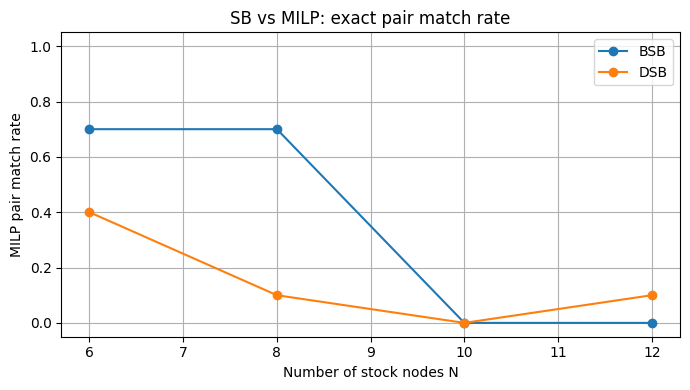

In [76]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_442_sb_vs_milp[
        summary_442_sb_vs_milp["variant"] == variant
    ].sort_values("N")

    plt.plot(
        part["N"],
        part["exact_match_pair_rate"],
        marker="o",
        label=variant,
    )

plt.xlabel("Number of stock nodes N")
plt.ylabel("MILP pair match rate")
plt.title("SB vs MILP: exact pair match rate")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_04_02_sb_vs_milp_pair_match_rate.png", dpi=300)
plt.show()

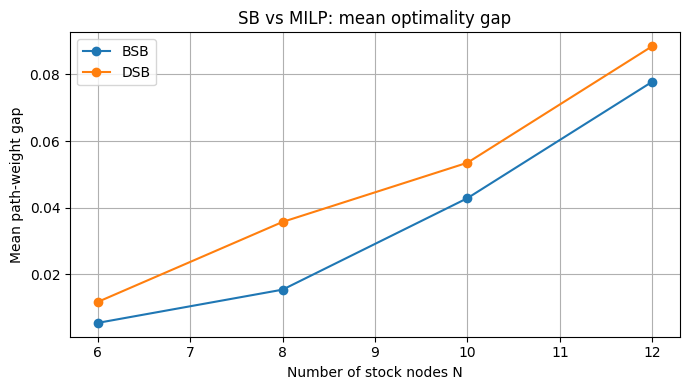

In [77]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_442_sb_vs_milp[
        summary_442_sb_vs_milp["variant"] == variant
    ].sort_values("N")

    plt.plot(
        part["N"],
        part["mean_gap"],
        marker="o",
        label=variant,
    )

plt.xlabel("Number of stock nodes N")
plt.ylabel("Mean path-weight gap")
plt.title("SB vs MILP: mean optimality gap")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_04_02_sb_vs_milp_mean_gap.png", dpi=300)
plt.show()

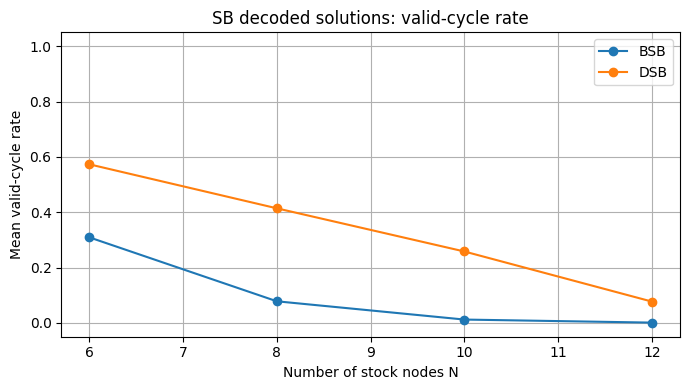

In [78]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_442_sb_vs_milp[
        summary_442_sb_vs_milp["variant"] == variant
    ].sort_values("N")

    plt.plot(
        part["N"],
        part["mean_valid_rate"],
        marker="o",
        label=variant,
    )

plt.xlabel("Number of stock nodes N")
plt.ylabel("Mean valid-cycle rate")
plt.title("SB decoded solutions: valid-cycle rate")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_04_02_sb_vs_milp_valid_rate.png", dpi=300)
plt.show()

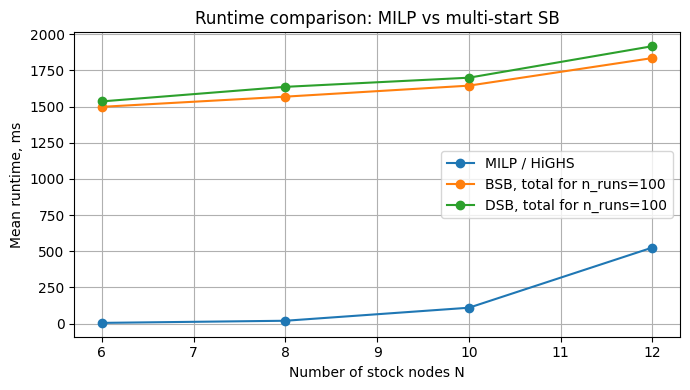

In [79]:
plt.figure(figsize=(7, 4))

plt.plot(
    summary_442_milp_runtime_large["N"],
    summary_442_milp_runtime_large["mean_milp_runtime_ms"],
    marker="o",
    label="MILP / HiGHS",
)

for variant in ["BSB", "DSB"]:
    part = summary_442_sb_vs_milp[
        summary_442_sb_vs_milp["variant"] == variant
    ].sort_values("N")

    plt.plot(
        part["N"],
        part["mean_total_runtime_ms"],
        marker="o",
        label=f"{variant}, total for n_runs={N_RUNS_SB_MILP}",
    )

plt.xlabel("Number of stock nodes N")
plt.ylabel("Mean runtime, ms")
plt.title("Runtime comparison: MILP vs multi-start SB")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_04_02_runtime_milp_vs_sb.png", dpi=300)
plt.show()

In [80]:
results_442_sb_vs_milp_raw.to_csv(
    "results_04_04_02_sb_vs_milp_raw.csv",
    index=False,
)

results_442_milp_baseline.to_csv(
    "results_04_04_02_milp_baseline.csv",
    index=False,
)

summary_442_sb_vs_milp.to_csv(
    "summary_04_04_02_sb_vs_milp.csv",
    index=False,
)

summary_442_milp_runtime_large.to_csv(
    "summary_04_04_02_milp_runtime_large.csv",
    index=False,
)

runtime_comparison_442.to_csv(
    "summary_04_04_02_runtime_comparison.csv",
    index=False,
)

print("Saved SB vs MILP results.")

Saved SB vs MILP results.


# 4.4.3. Simulated annealing / tabu search

В этом блоке SB сравнивается с классическими эвристиками:

1. simulated annealing;
2. tabu search.

В отличие от SB, который решает QUBO/Ising-задачу и затем требует декодирования dummy-cycle, классические эвристики работают напрямую в пространстве допустимых простых путей:

$$
\text{short} \to \ldots \to \text{long}.
$$

Такой подход автоматически сохраняет валидность решения, поскольку каждый candidate path строится как простой путь без повторения вершин.

MILP / HiGHS используется как exact baseline.

In [81]:
def make_cycle_from_path(path):
    """
    path: [short, ..., long]
    returns: [0, short, ..., long, 0]
    """
    return [0] + list(path) + [0]


def random_path(N, rng, min_len=2):
    """
    Генерирует случайный простой путь по stock nodes 1..N.
    """
    length = rng.integers(min_len, N + 1)
    return list(rng.choice(np.arange(1, N + 1), size=length, replace=False))


def path_cost(path, w):
    """
    Стоимость пути short -> ... -> long.
    """
    return path_weight(path, w)


def path_to_solution(path, w):
    """
    Приводит path к формату, похожему на результат других solver'ов.
    """
    cycle = make_cycle_from_path(path)

    return {
        "cycle": cycle,
        "selected_edges": list(zip(cycle[:-1], cycle[1:])),
        "short_node": path[0],
        "long_node": path[-1],
        "path_nodes": list(path),
        "path_weight": path_cost(path, w),
    }

In [ ]:
def propose_neighbor(path, N, rng):
    """
    Случайное локальное изменение пути.

    Возможные варианты:
    - replace: заменить одну вершину на неиспользованную;
    - insert: вставить неиспользованную вершину;
    - delete: удалить вершину, если длина > 2;
    - swap: поменять две позиции;
    - reverse_segment: развернуть часть пути.
    """
    path = list(path)
    used = set(path)
    all_nodes = set(range(1, N + 1))
    unused = list(all_nodes - used)

    possible_moves = ["swap", "reverse_segment"]

    if unused:
        possible_moves.extend(["replace", "insert"])

    if len(path) > 2:
        possible_moves.append("delete")

    move = rng.choice(possible_moves)

    new_path = path.copy()

    if move == "replace":
        pos = rng.integers(0, len(path))
        new_node = rng.choice(unused)
        new_path[pos] = int(new_node)

    elif move == "insert":
        pos = rng.integers(0, len(path) + 1)
        new_node = rng.choice(unused)
        new_path.insert(pos, int(new_node))

    elif move == "delete":
        pos = rng.integers(0, len(path))
        del new_path[pos]

    elif move == "swap":
        if len(path) >= 2:
            i, j = rng.choice(len(path), size=2, replace=False)
            new_path[i], new_path[j] = new_path[j], new_path[i]

    elif move == "reverse_segment":
        if len(path) >= 2:
            i, j = sorted(rng.choice(len(path), size=2, replace=False))
            new_path[i:j+1] = reversed(new_path[i:j+1])

    assert len(new_path) >= 2
    assert len(new_path) == len(set(new_path))

    return new_path

In [83]:
def solve_path_simulated_annealing(
    w,
    n_iter=2000,
    n_restarts=20,
    T0=0.05,
    Tmin=1e-4,
    seed=42,
):
    """
    Simulated annealing в пространстве допустимых простых путей.
    """
    w = np.asarray(w, dtype=float)
    N = w.shape[0] - 1
    rng = np.random.default_rng(seed)

    best_path = None
    best_cost = np.inf

    start_time = time.perf_counter()

    for restart in range(n_restarts):
        current_path = random_path(N, rng)
        current_cost = path_cost(current_path, w)

        if current_cost < best_cost:
            best_cost = current_cost
            best_path = current_path.copy()

        for t in range(n_iter):
            alpha = t / max(1, n_iter - 1)
            T = T0 * (Tmin / T0) ** alpha

            candidate_path = propose_neighbor(current_path, N, rng)
            candidate_cost = path_cost(candidate_path, w)

            delta = candidate_cost - current_cost

            if delta <= 0:
                accept = True
            else:
                accept = rng.random() < np.exp(-delta / max(T, 1e-12))

            if accept:
                current_path = candidate_path
                current_cost = candidate_cost

                if current_cost < best_cost:
                    best_cost = current_cost
                    best_path = current_path.copy()

    runtime_sec = time.perf_counter() - start_time

    sol = path_to_solution(best_path, w)
    sol["runtime_sec"] = runtime_sec
    sol["algorithm"] = "SA"

    return sol

In [ ]:
def solve_path_tabu_search(
    w,
    n_iter=1000,
    n_restarts=20,
    neighborhood_size=100,
    tabu_tenure=50,
    seed=42,
):
    """
    Tabu search в пространстве допустимых простых путей.

    Tabu list хранит недавно посещённые пути.
    """
    w = np.asarray(w, dtype=float)
    N = w.shape[0] - 1
    rng = np.random.default_rng(seed)

    best_path = None
    best_cost = np.inf

    start_time = time.perf_counter()

    for restart in range(n_restarts):
        current_path = random_path(N, rng)
        current_cost = path_cost(current_path, w)

        tabu_list = []
        tabu_set = set()

        for t in range(n_iter):
            candidates = []

            for _ in range(neighborhood_size):
                cand_path = propose_neighbor(current_path, N, rng)
                cand_cost = path_cost(cand_path, w)
                cand_key = tuple(cand_path)

                is_tabu = cand_key in tabu_set
                aspiration = cand_cost < best_cost

                if (not is_tabu) or aspiration:
                    candidates.append((cand_cost, cand_path, cand_key))

            if not candidates:
                continue

            candidates.sort(key=lambda x: x[0])
            next_cost, next_path, next_key = candidates[0]

            current_path = next_path
            current_cost = next_cost

            tabu_list.append(next_key)
            tabu_set.add(next_key)

            if len(tabu_list) > tabu_tenure:
                old_key = tabu_list.pop(0)
                tabu_set.remove(old_key)

            if current_cost < best_cost:
                best_cost = current_cost
                best_path = current_path.copy()

    runtime_sec = time.perf_counter() - start_time

    sol = path_to_solution(best_path, w)
    sol["runtime_sec"] = runtime_sec
    sol["algorithm"] = "Tabu"

    return sol

In [85]:
def compare_path_heuristic_to_milp(heuristic_solution, milp_solution, algorithm):
    """
    Сравнение SA/Tabu с MILP baseline.
    """
    same_pair = (
        heuristic_solution["short_node"] == milp_solution["short_node"]
        and heuristic_solution["long_node"] == milp_solution["long_node"]
    )

    same_path = heuristic_solution["path_nodes"] == milp_solution["path_nodes"]

    return {
        "algorithm": algorithm,
        "milp_path_weight": milp_solution["path_weight"],
        "solver_path_weight": heuristic_solution["path_weight"],
        "gap": heuristic_solution["path_weight"] - milp_solution["path_weight"],
        "same_pair": same_pair,
        "same_path": same_path,
        "milp_cycle": milp_solution["cycle"],
        "solver_cycle": heuristic_solution["cycle"],
        "runtime_ms": 1000 * heuristic_solution["runtime_sec"],
    }

In [86]:
toy_classical = generate_toy_market_graph(N=8, seed=777)
w_classical = toy_classical["w"]

milp_classical = solve_cycle_milp_highs(w_classical)

sa_solution = solve_path_simulated_annealing(
    w_classical,
    n_iter=2000,
    n_restarts=20,
    T0=0.05,
    Tmin=1e-4,
    seed=1,
)

tabu_solution = solve_path_tabu_search(
    w_classical,
    n_iter=1000,
    n_restarts=20,
    neighborhood_size=100,
    tabu_tenure=50,
    seed=1,
)

pd.DataFrame([
    compare_path_heuristic_to_milp(sa_solution, milp_classical, "SA"),
    compare_path_heuristic_to_milp(tabu_solution, milp_classical, "Tabu"),
])

,algorithm,milp_path_weight,solver_path_weight,gap,same_pair,same_path,milp_cycle,solver_cycle,runtime_ms
0,SA,-0.054535,-0.054535,0.0,True,True,"[0, 4, 6, 7, 2, 8, 5, 0]","[0, 4, 6, 7, 2, 8, 5, 0]",2116.0905
1,Tabu,-0.054535,-0.054535,0.0,True,True,"[0, 4, 6, 7, 2, 8, 5, 0]","[0, 4, 6, 7, 2, 8, 5, 0]",95917.2255


In [87]:
N_VALUES_CLASSICAL = [6, 8, 10, 12]
N_INSTANCES_CLASSICAL = 10

BASE_SEED_CLASSICAL = 7070

SA_PARAMS = {
    "n_iter": 2000,
    "n_restarts": 20,
    "T0": 0.05,
    "Tmin": 1e-4,
}

TABU_PARAMS = {
    "n_iter": 1000,
    "n_restarts": 20,
    "neighborhood_size": 100,
    "tabu_tenure": 50,
}

In [88]:
classical_vs_milp_rows = []
classical_milp_baseline_rows = []

for N in N_VALUES_CLASSICAL:
    print(f"N = {N}")

    for instance_id in range(N_INSTANCES_CLASSICAL):
        print(f"  instance {instance_id}")

        toy = generate_toy_market_graph(
            N=N,
            seed=BASE_SEED_CLASSICAL + 1000 * N + instance_id,
        )

        w = toy["w"]

        milp_solution = solve_cycle_milp_highs(w)

        assert milp_solution["success"]
        assert milp_solution["is_valid_dummy_cycle"]

        classical_milp_baseline_rows.append({
            "N": N,
            "instance_id": instance_id,
            "milp_path_weight": milp_solution["path_weight"],
            "milp_cycle": milp_solution["cycle"],
            "milp_runtime_ms": 1000 * milp_solution["runtime_sec"],
        })

        sa_solution = solve_path_simulated_annealing(
            w=w,
            seed=BASE_SEED_CLASSICAL + 10_000 * N + 100 * instance_id,
            **SA_PARAMS,
        )

        tabu_solution = solve_path_tabu_search(
            w=w,
            seed=BASE_SEED_CLASSICAL + 20_000 * N + 100 * instance_id,
            **TABU_PARAMS,
        )

        for sol, alg in [
            (sa_solution, "SA"),
            (tabu_solution, "Tabu"),
        ]:
            row = compare_path_heuristic_to_milp(
                heuristic_solution=sol,
                milp_solution=milp_solution,
                algorithm=alg,
            )

            row.update({
                "N": N,
                "instance_id": instance_id,
            })

            classical_vs_milp_rows.append(row)

results_443_classical_vs_milp_raw = pd.DataFrame(classical_vs_milp_rows)
results_443_milp_baseline = pd.DataFrame(classical_milp_baseline_rows)

results_443_classical_vs_milp_raw.head()

N = 6
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
  instance 5
  instance 6
  instance 7
  instance 8
  instance 9
N = 8
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
  instance 5
  instance 6
  instance 7
  instance 8
  instance 9
N = 10
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
  instance 5
  instance 6
  instance 7
  instance 8
  instance 9
N = 12
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
  instance 5
  instance 6
  instance 7
  instance 8
  instance 9


,algorithm,milp_path_weight,solver_path_weight,gap,same_pair,same_path,milp_cycle,solver_cycle,runtime_ms,N,instance_id
0,SA,-0.038593,-0.038593,0.0,True,True,"[0, 4, 5, 3, 1, 0]","[0, 4, 5, 3, 1, 0]",2138.9671,6,0
1,Tabu,-0.038593,-0.038593,0.0,True,True,"[0, 4, 5, 3, 1, 0]","[0, 4, 5, 3, 1, 0]",94335.8456,6,0
2,SA,-0.064067,-0.064067,0.0,True,True,"[0, 5, 6, 0]","[0, 5, 6, 0]",2212.3499,6,1
3,Tabu,-0.064067,-0.064067,0.0,True,True,"[0, 5, 6, 0]","[0, 5, 6, 0]",93989.7739,6,1
4,SA,-0.051709,-0.051709,0.0,True,True,"[0, 3, 2, 5, 4, 1, 0]","[0, 3, 2, 5, 4, 1, 0]",2202.9791,6,2


In [89]:
summary_443_classical_vs_milp = (
    results_443_classical_vs_milp_raw
    .groupby(["N", "algorithm"], as_index=False)
    .agg(
        exact_match_pair_rate=("same_pair", "mean"),
        exact_match_path_rate=("same_path", "mean"),
        mean_gap=("gap", "mean"),
        median_gap=("gap", "median"),
        max_gap=("gap", "max"),
        mean_runtime_ms=("runtime_ms", "mean"),
        n_graphs=("instance_id", "nunique"),
    )
)

summary_443_classical_vs_milp

,N,algorithm,exact_match_pair_rate,exact_match_path_rate,mean_gap,median_gap,max_gap,mean_runtime_ms,n_graphs
0,6,SA,1.0,1.0,0.000000,0.000000,0.000000,2140.58360,10
1,6,Tabu,1.0,1.0,0.000000,0.000000,0.000000,93212.47920,10
2,8,SA,1.0,1.0,0.000000,0.000000,0.000000,2146.35167,10
3,8,Tabu,1.0,1.0,0.000000,0.000000,0.000000,93783.83022,10
4,10,SA,0.9,0.8,0.000358,0.000000,0.002165,2169.63549,10
5,10,Tabu,1.0,1.0,0.000000,0.000000,0.000000,96327.05589,10
6,12,SA,0.7,0.4,0.002411,0.002672,0.006365,2189.78393,10
7,12,Tabu,1.0,1.0,0.000000,0.000000,0.000000,97106.74441,10


In [90]:
summary_443_milp_runtime = (
    results_443_milp_baseline
    .groupby("N", as_index=False)
    .agg(
        mean_milp_runtime_ms=("milp_runtime_ms", "mean"),
        max_milp_runtime_ms=("milp_runtime_ms", "max"),
        n_graphs=("instance_id", "nunique"),
    )
)

summary_443_milp_runtime

,N,mean_milp_runtime_ms,max_milp_runtime_ms,n_graphs
0,6,5.04960,7.5122,10
1,8,15.05764,22.7423,10
2,10,74.07342,161.8504,10
3,12,563.84914,1847.0663,10


In [103]:
summary_442_for_merge = summary_442_sb_vs_milp.rename(
    columns={
        "variant": "algorithm",
        "mean_total_runtime_ms": "mean_runtime_ms",
    }
)

summary_442_for_merge = summary_442_for_merge[
    [
        "N",
        "algorithm",
        "mean_valid_rate",
        "exact_match_pair_rate",
        "exact_match_path_rate",
        "mean_gap",
        "median_gap",
        "max_gap",
        "mean_runtime_ms",
        "n_graphs",
    ]
]

summary_443_all_heuristics = pd.concat(
    [
        summary_442_for_merge,
        summary_443_classical_vs_milp,
    ],
    ignore_index=True,
)

summary_443_all_heuristics

,N,algorithm,mean_valid_rate,exact_match_pair_rate,exact_match_path_rate,mean_gap,median_gap,max_gap,mean_runtime_ms,n_graphs
0,6,BSB,0.309,0.7,0.2,0.005478,0.005075,0.014064,1498.54231,10
1,6,DSB,0.573,0.4,0.1,0.011762,0.009960,0.036573,1536.07771,10
2,8,BSB,0.078,0.7,0.0,0.015446,0.013947,0.031865,1568.92911,10
3,8,DSB,0.414,0.1,0.0,0.035750,0.034968,0.058498,1636.72834,10
4,10,BSB,0.012,0.0,0.0,0.042876,0.046980,0.053422,1645.03690,10
5,10,DSB,0.258,0.0,0.0,0.053501,0.050611,0.080116,1699.98012,10
6,12,BSB,0.001,0.0,0.0,0.077789,0.077789,0.077789,1835.73460,10
7,12,DSB,0.077,0.1,0.0,0.088452,0.084425,0.139067,1917.84407,10
8,6,SA,NaN,1.0,1.0,0.000000,0.000000,0.000000,2140.58360,10
9,6,Tabu,NaN,1.0,1.0,0.000000,0.000000,0.000000,93212.47920,10


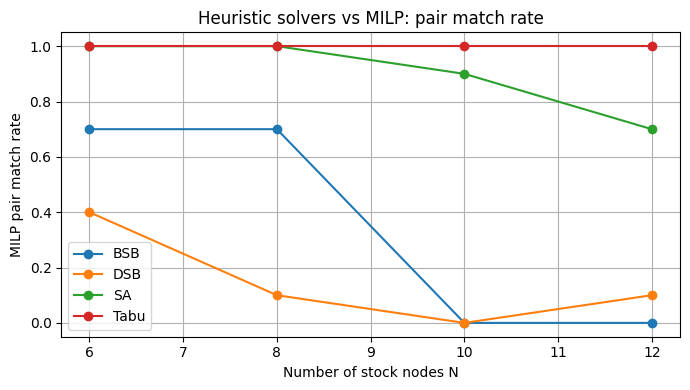

In [92]:
plt.figure(figsize=(7, 4))

for algorithm in summary_443_all_heuristics["algorithm"].unique():
    part = summary_443_all_heuristics[
        summary_443_all_heuristics["algorithm"] == algorithm
    ].sort_values("N")

    plt.plot(
        part["N"],
        part["exact_match_pair_rate"],
        marker="o",
        label=algorithm,
    )

plt.xlabel("Number of stock nodes N")
plt.ylabel("MILP pair match rate")
plt.title("Heuristic solvers vs MILP: pair match rate")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_04_03_heuristics_pair_match_rate.png", dpi=300)
plt.show()

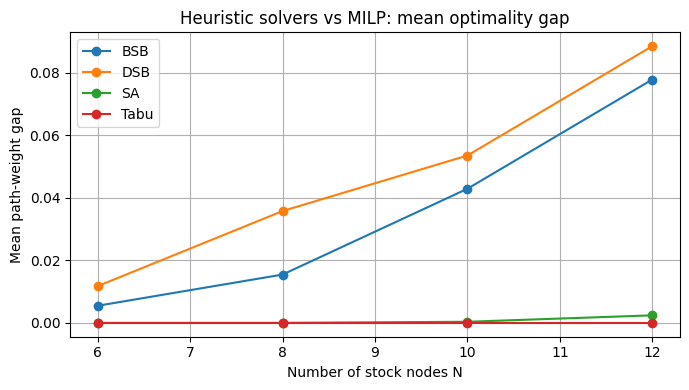

In [93]:
plt.figure(figsize=(7, 4))

for algorithm in summary_443_all_heuristics["algorithm"].unique():
    part = summary_443_all_heuristics[
        summary_443_all_heuristics["algorithm"] == algorithm
    ].sort_values("N")

    plt.plot(
        part["N"],
        part["mean_gap"],
        marker="o",
        label=algorithm,
    )

plt.xlabel("Number of stock nodes N")
plt.ylabel("Mean path-weight gap")
plt.title("Heuristic solvers vs MILP: mean optimality gap")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_04_03_heuristics_mean_gap.png", dpi=300)
plt.show()

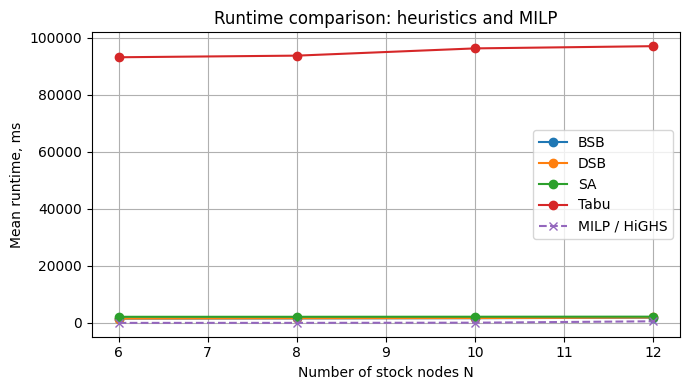

In [94]:
plt.figure(figsize=(7, 4))

for algorithm in summary_443_all_heuristics["algorithm"].unique():
    part = summary_443_all_heuristics[
        summary_443_all_heuristics["algorithm"] == algorithm
    ].sort_values("N")

    plt.plot(
        part["N"],
        part["mean_runtime_ms"],
        marker="o",
        label=algorithm,
    )

plt.plot(
    summary_443_milp_runtime["N"],
    summary_443_milp_runtime["mean_milp_runtime_ms"],
    marker="x",
    linestyle="--",
    label="MILP / HiGHS",
)

plt.xlabel("Number of stock nodes N")
plt.ylabel("Mean runtime, ms")
plt.title("Runtime comparison: heuristics and MILP")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_04_03_heuristics_runtime.png", dpi=300)
plt.show()

In [95]:
results_443_classical_vs_milp_raw.to_csv(
    "results_04_04_03_classical_vs_milp_raw.csv",
    index=False,
)

summary_443_classical_vs_milp.to_csv(
    "summary_04_04_03_classical_vs_milp.csv",
    index=False,
)

summary_443_milp_runtime.to_csv(
    "summary_04_04_03_milp_runtime.csv",
    index=False,
)

summary_443_all_heuristics.to_csv(
    "summary_04_04_03_all_heuristics.csv",
    index=False,
)

print("Saved 4.4.3 classical heuristic comparison results.")

Saved 4.4.3 classical heuristic comparison results.


# 4.4.4. Метрики качества и времени

Для сравнения решателей используются метрики качества и времени.

Пусть $E^\ast$ — точное значение, найденное MILP / HiGHS, а $E_{\mathrm{solver}}$ — значение, найденное рассматриваемым решателем.

Основная метрика качества:

$$
\Delta E = E_{\mathrm{solver}} - E^\ast.
$$

Так как задача является задачей минимизации, для корректного решения должно выполняться

$$
\Delta E \geq 0.
$$

Также используются следующие метрики:

1. **Exact pair match rate** — доля случаев, когда solver нашёл те же конечные пары, что и MILP:

$$
(\text{short}_{\mathrm{solver}}, \text{long}_{\mathrm{solver}})
=
(\text{short}_{\mathrm{MILP}}, \text{long}_{\mathrm{MILP}}).
$$

2. **Exact path match rate** — доля случаев, когда solver нашёл полностью тот же путь, что и MILP.

3. **Mean gap** — среднее значение $\Delta E$ по набору графов.

4. **Median gap** — медианный optimality gap.

5. **Max gap** — максимальный gap на тестовом наборе.

6. **Runtime** — среднее время работы решателя на одном графе.

Для SB дополнительно учитывается **valid-cycle rate**, поскольку SB сначала решает QUBO/Ising-задачу, а затем полученная бинарная конфигурация декодируется в dummy-cycle. Не каждый запуск SB даёт валидный цикл.

In [96]:
# summary_443_all_heuristics содержит BSB, DSB, SA, Tabu
# summary_443_milp_runtime содержит runtime для MILP

final_heuristics_table = summary_443_all_heuristics.copy()

# Для SA и Tabu решения всегда валидны, потому что они работают в пространстве допустимых путей.
# Для BSB/DSB valid-rate был в отдельной таблице summary_442_sb_vs_milp.
# Если valid-rate нет, поставим NaN, а ниже аккуратно заполним.

if "mean_valid_rate" not in final_heuristics_table.columns:
    final_heuristics_table["mean_valid_rate"] = np.nan

# Добавляем MILP как exact baseline
milp_rows = []

for _, row in summary_443_milp_runtime.iterrows():
    milp_rows.append({
        "N": row["N"],
        "algorithm": "MILP / HiGHS",
        "exact_match_pair_rate": 1.0,
        "exact_match_path_rate": 1.0,
        "mean_gap": 0.0,
        "median_gap": 0.0,
        "max_gap": 0.0,
        "mean_runtime_ms": row["mean_milp_runtime_ms"],
        "n_graphs": row["n_graphs"],
        "mean_valid_rate": 1.0,
    })

milp_table = pd.DataFrame(milp_rows)

final_solver_comparison = pd.concat(
    [milp_table, final_heuristics_table],
    ignore_index=True,
)

# Для SA и Tabu valid-rate = 1, потому что они строят только допустимые пути
final_solver_comparison.loc[
    final_solver_comparison["algorithm"].isin(["SA", "Tabu"]),
    "mean_valid_rate"
] = 1.0

final_solver_comparison = final_solver_comparison[
    [
        "N",
        "algorithm",
        "mean_valid_rate",
        "exact_match_pair_rate",
        "exact_match_path_rate",
        "mean_gap",
        "median_gap",
        "max_gap",
        "mean_runtime_ms",
        "n_graphs",
    ]
].sort_values(["N", "algorithm"]).reset_index(drop=True)

final_solver_comparison

,N,algorithm,mean_valid_rate,exact_match_pair_rate,exact_match_path_rate,mean_gap,median_gap,max_gap,mean_runtime_ms,n_graphs
0,6.0,BSB,NaN,0.7,0.2,0.005478,0.005075,0.014064,1498.54231,10.0
1,6.0,DSB,NaN,0.4,0.1,0.011762,0.009960,0.036573,1536.07771,10.0
2,6.0,MILP / HiGHS,1.0,1.0,1.0,0.000000,0.000000,0.000000,5.04960,10.0
3,6.0,SA,1.0,1.0,1.0,0.000000,0.000000,0.000000,2140.58360,10.0
4,6.0,Tabu,1.0,1.0,1.0,0.000000,0.000000,0.000000,93212.47920,10.0
5,8.0,BSB,NaN,0.7,0.0,0.015446,0.013947,0.031865,1568.92911,10.0
6,8.0,DSB,NaN,0.1,0.0,0.035750,0.034968,0.058498,1636.72834,10.0
7,8.0,MILP / HiGHS,1.0,1.0,1.0,0.000000,0.000000,0.000000,15.05764,10.0
8,8.0,SA,1.0,1.0,1.0,0.000000,0.000000,0.000000,2146.35167,10.0
9,8.0,Tabu,1.0,1.0,1.0,0.000000,0.000000,0.000000,93783.83022,10.0


In [97]:
final_solver_comparison_display = final_solver_comparison.copy()

round_cols = [
    "mean_valid_rate",
    "exact_match_pair_rate",
    "exact_match_path_rate",
    "mean_gap",
    "median_gap",
    "max_gap",
    "mean_runtime_ms",
]

for col in round_cols:
    final_solver_comparison_display[col] = final_solver_comparison_display[col].round(4)

final_solver_comparison_display

,N,algorithm,mean_valid_rate,exact_match_pair_rate,exact_match_path_rate,mean_gap,median_gap,max_gap,mean_runtime_ms,n_graphs
0,6.0,BSB,NaN,0.7,0.2,0.0055,0.0051,0.0141,1498.5423,10.0
1,6.0,DSB,NaN,0.4,0.1,0.0118,0.0100,0.0366,1536.0777,10.0
2,6.0,MILP / HiGHS,1.0,1.0,1.0,0.0000,0.0000,0.0000,5.0496,10.0
3,6.0,SA,1.0,1.0,1.0,0.0000,0.0000,0.0000,2140.5836,10.0
4,6.0,Tabu,1.0,1.0,1.0,0.0000,0.0000,0.0000,93212.4792,10.0
5,8.0,BSB,NaN,0.7,0.0,0.0154,0.0139,0.0319,1568.9291,10.0
6,8.0,DSB,NaN,0.1,0.0,0.0358,0.0350,0.0585,1636.7283,10.0
7,8.0,MILP / HiGHS,1.0,1.0,1.0,0.0000,0.0000,0.0000,15.0576,10.0
8,8.0,SA,1.0,1.0,1.0,0.0000,0.0000,0.0000,2146.3517,10.0
9,8.0,Tabu,1.0,1.0,1.0,0.0000,0.0000,0.0000,93783.8302,10.0


In [98]:
quality_ranking = (
    final_solver_comparison
    .groupby("algorithm", as_index=False)
    .agg(
        mean_valid_rate=("mean_valid_rate", "mean"),
        mean_pair_match=("exact_match_pair_rate", "mean"),
        mean_path_match=("exact_match_path_rate", "mean"),
        mean_gap=("mean_gap", "mean"),
        median_gap=("median_gap", "mean"),
        mean_runtime_ms=("mean_runtime_ms", "mean"),
    )
)

quality_ranking = quality_ranking.sort_values(
    ["mean_gap", "mean_pair_match"],
    ascending=[True, False],
).reset_index(drop=True)

quality_ranking

,algorithm,mean_valid_rate,mean_pair_match,mean_path_match,mean_gap,median_gap,mean_runtime_ms
0,MILP / HiGHS,1.0,1.00,1.000,0.000000,0.000000,164.507450
1,Tabu,1.0,1.00,1.000,0.000000,0.000000,95107.527430
2,SA,1.0,0.90,0.800,0.000692,0.000668,2161.588672
3,BSB,NaN,0.35,0.050,0.035397,0.035948,1637.060730
4,DSB,NaN,0.15,0.025,0.047366,0.044991,1697.657560


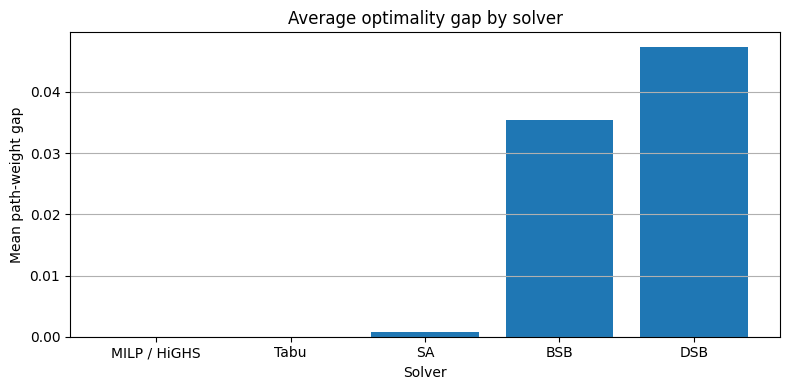

In [99]:
plt.figure(figsize=(8, 4))

plot_df = quality_ranking.sort_values("mean_gap")

plt.bar(
    plot_df["algorithm"],
    plot_df["mean_gap"],
)

plt.xlabel("Solver")
plt.ylabel("Mean path-weight gap")
plt.title("Average optimality gap by solver")
plt.grid(axis="y")
plt.tight_layout()

plt.savefig("fig_04_04_04_final_mean_gap_by_solver.png", dpi=300)
plt.show()

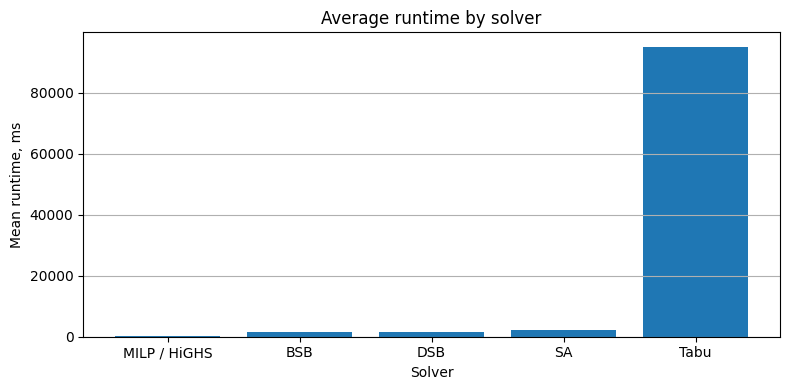

In [100]:
plt.figure(figsize=(8, 4))

plot_df = quality_ranking.sort_values("mean_runtime_ms")

plt.bar(
    plot_df["algorithm"],
    plot_df["mean_runtime_ms"],
)

plt.xlabel("Solver")
plt.ylabel("Mean runtime, ms")
plt.title("Average runtime by solver")
plt.grid(axis="y")
plt.tight_layout()

plt.savefig("fig_04_04_04_final_runtime_by_solver.png", dpi=300)
plt.show()

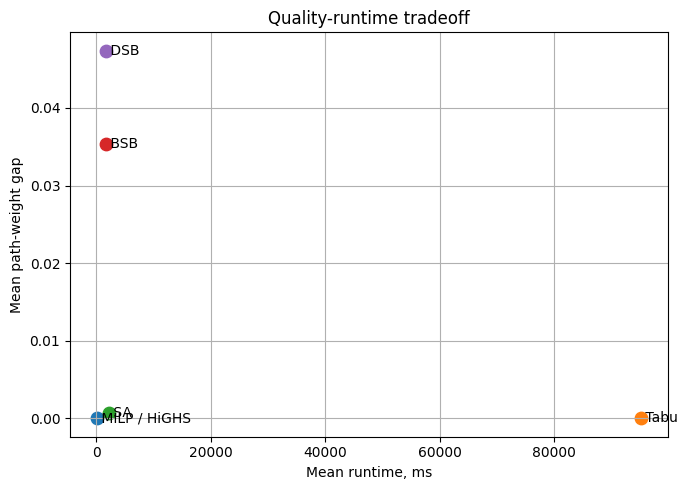

In [101]:
plt.figure(figsize=(7, 5))

for _, row in quality_ranking.iterrows():
    plt.scatter(
        row["mean_runtime_ms"],
        row["mean_gap"],
        s=80,
    )
    plt.text(
        row["mean_runtime_ms"],
        row["mean_gap"],
        " " + row["algorithm"],
        va="center",
    )

plt.xlabel("Mean runtime, ms")
plt.ylabel("Mean path-weight gap")
plt.title("Quality-runtime tradeoff")
plt.grid(True)
plt.tight_layout()

plt.savefig("fig_04_04_04_quality_runtime_tradeoff.png", dpi=300)
plt.show()

In [102]:
final_solver_comparison.to_csv(
    "summary_04_04_04_final_solver_comparison.csv",
    index=False,
)

final_solver_comparison_display.to_csv(
    "summary_04_04_04_final_solver_comparison_display.csv",
    index=False,
)

quality_ranking.to_csv(
    "summary_04_04_04_quality_ranking.csv",
    index=False,
)

print("Saved final 4.4.4 solver comparison tables.")

Saved final 4.4.4 solver comparison tables.
